# Neural Networks

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay, accuracy_score, classification_report, f1_score, recall_score, precision_score, roc_auc_score, average_precision_score, precision_recall_curve
from keras.models import Sequential
from keras.layers import Dense, Activation, Input, Dropout
from keras.optimizers import Adam
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import GridSearchCV
from scikeras.wrappers import KerasClassifier
from run_models import run_models
import itertools
from tqdm import tqdm
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, SGD, RMSprop, AdamW
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [11]:
GLOBAL_SEED = 42 
N_JOBS = -1
np.random.seed(GLOBAL_SEED)

In [12]:
df =pd.read_csv('cleaned_heart_attack.csv')
X = df.drop('HeartDiseaseorAttack', axis=1)
Y = df['HeartDiseaseorAttack']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=GLOBAL_SEED, stratify=Y)

In [13]:
def create_preprocessor(continuous_features, categorical_features, binary_features, scaler_type='standard'):
    """
    Creates a scikit-learn ColumnTransformer to preprocess data.
    
    This preprocessor applies three steps:
    1. A specified scaler to continuous features.
    2. One-Hot Encoding to multi-level categorical features.
    3. Passthrough to binary features.

    Parameters
    ----------
    continuous_features : list
        List of column names to be scaled.
    categorical_features : list
        List of column names to be one-hot encoded.
    binary_features : list
        List of column names to be passed through untouched.
    scaler_type : str, optional
        The type of scaler to use. Options are:
        - 'standard' (default)
        - 'minmax'
        - 'robust'
    """
    
    # Select the scaler based on the input string
    if scaler_type == 'standard':
        scaler = StandardScaler()
    elif scaler_type == 'minmax':
        scaler = MinMaxScaler()
    elif scaler_type == 'robust':
        scaler = RobustScaler()
    else:
        raise ValueError(f"Unknown scaler_type: '{scaler_type}'. "
                         f"Choose from 'standard', 'minmax', or 'robust'.")
    
    # Create the preprocessor with the chosen scaler
    preprocessor = ColumnTransformer(
        transformers=[
            # Step 1: Scale the true continuous features
            ('scale', scaler, continuous_features),

            # Step 2: One-Hot Encode the multi-level categorical features
            ('onehot', OneHotEncoder(handle_unknown='ignore'), categorical_features),

            # Step 3: Pass through the binary features (all other columns)
            ('pass', 'passthrough', binary_features)
        ]
    )
    
    return preprocessor

### We need the val data to be non smote to actually monitor performance for callbacks like early stopping

## Scaling

In [14]:
# --- 1. True Continuous Features (Need Scaling) ---
# These are real measurements on a continuous scale.
continuous_features = ['BMI', 'MentHlth', 'PhysHlth']

# --- 2. Binary Features (Pass through as-is) ---
# These are already 0 or 1. Don't touch them.
binary_features = [
    'HighBP', 'HighChol', 'CholCheck', 'Smoker', 'Stroke', 
    'PhysActivity', 'HvyAlcoholConsump', 'Sex'
]

# --- 3. Multi-Level Categorical Features (Need One-Hot Encoding) ---
# These have multiple categories (like 0,1,2 or 1-13) where
# the numbers don't have a true mathematical relationship.
categorical_features = ['Diabetes', 'Age', 'Education', 'Income']

preprocessor_robust = create_preprocessor(
    continuous_features, 
    categorical_features, 
    binary_features, 
    scaler_type='robust'
)

X_train_robust = preprocessor_robust.fit_transform(X_train)
X_test_robust = preprocessor_robust.transform(X_test)


preprocessor_minmax = create_preprocessor(
    continuous_features, 
    categorical_features, 
    binary_features, 
    scaler_type='minmax'
)

X_train_minmax = preprocessor_minmax.fit_transform(X_train)
X_test_minmax = preprocessor_minmax.transform(X_test)
 

preprocessor_standard = create_preprocessor(
    continuous_features,
    categorical_features,
    binary_features,
    scaler_type='standard'
)

X_train_standard = preprocessor_standard.fit_transform(X_train)
X_test_standard = preprocessor_standard.transform(X_test)

# --- 4. Models that DON'T need scaling (Tree-based) ---
# For Random Forest, XGBoost, etc., you don't use this preprocessor.
# You still need to one-hot encode, but not scale.
preprocessor_trees = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('pass', 'passthrough', continuous_features + binary_features)
    ]
)

X_train_trees = preprocessor_trees.fit_transform(X_train)
X_test_trees = preprocessor_trees.transform(X_test)

scaler = StandardScaler()
X_train_standard_all = scaler.fit_transform(X_train)
X_test_standard_all = scaler.transform(X_test)

In [15]:
X_TRAIN, X_VAL, Y_TRAIN, Y_VAL = train_test_split(
    X_train_minmax, Y_train, test_size=0.1, random_state=GLOBAL_SEED, stratify=Y_train
)
X_TEST = X_test_minmax
Y_TEST = Y_test

In [16]:
from imblearn.under_sampling import TomekLinks, EditedNearestNeighbours
from imblearn.combine import SMOTEENN, SMOTETomek
from imblearn.over_sampling import SMOTE


#target_ratio = 0.25
# Calculate the actual ratio of the minority class in the training data
actual_minority_count = Y_train.sum()
actual_majority_count = len(Y_train) - actual_minority_count
target_ratio = actual_minority_count / actual_majority_count

sm = SMOTE(random_state=GLOBAL_SEED)

smt = SMOTETomek(tomek=TomekLinks(sampling_strategy='all'), n_jobs=-N_JOBS, random_state=GLOBAL_SEED)


sme = SMOTEENN(
    random_state=GLOBAL_SEED,
    n_jobs=N_JOBS
)

X_resampled_sme, Y_resampled_sme = sme.fit_resample(X_TRAIN, Y_TRAIN)
X_resampled_sm, Y_resampled_sm = sm.fit_resample(X_TRAIN, Y_TRAIN)
X_resampled_smt, Y_resampled_smt = smt.fit_resample(X_TRAIN, Y_TRAIN)

In [17]:
def get_smotes(X_train, Y_train):
    #X_train, X_val, Y_train, Y_val = train_test_split(X_train, Y_train, test_size=0.1, random_state=GLOBAL_SEED, stratify=Y_train)
    sm = SMOTE(random_state=GLOBAL_SEED)
    sme = SMOTEENN(
        random_state=GLOBAL_SEED,
        n_jobs=N_JOBS
    )
    smt = SMOTETomek(tomek=TomekLinks(sampling_strategy='all'), n_jobs=-N_JOBS, random_state=GLOBAL_SEED)
    X_resampled_sm, Y_resampled_sm = sm.fit_resample(X_train, Y_train)
    X_resampled_sme, Y_resampled_sme = sme.fit_resample(X_train, Y_train)
    X_resampled_smt, Y_resampled_smt = smt.fit_resample(X_train, Y_train)
    return X_resampled_sm, Y_resampled_sm, X_resampled_sme, Y_resampled_sme, X_resampled_smt, Y_resampled_smt

## Plots

In [25]:
def evaluate_model(X_test, Y_test, model, model_name="Model", text_summary=False, history=None, save=None, threshold=False):
    cmap = "crest"
    # --- 1. Handle Keras vs Sklearn Predictions ---
    y_pred_raw = model.predict(X_test)
    

    # Apply threshold if predictions are probabilities
    if threshold is True:
        # Calculate the best threshold using precision-recall curve
        precision, recall, thresholds = precision_recall_curve(Y_test, y_pred_raw)
        f1_scores = 2 * (precision * recall) / (precision + recall)
        best_idx = np.argmax(f1_scores)
        best_threshold = thresholds[best_idx]
        print(f"Best threshold calculated: {best_threshold}")
        y_pred = (y_pred_raw >= best_threshold).astype(int).flatten()
    else:
       y_pred = (y_pred_raw > 0.5).astype(int).flatten()

    # --- 2. Confusion Matrix & Metrics ---
    cm = confusion_matrix(Y_test, y_pred)
    accuracy = accuracy_score(Y_test, y_pred)
    f1_binary = f1_score(Y_test, y_pred, average='binary')
    f1_macro = f1_score(Y_test, y_pred, average='macro')
    f1_weighted = f1_score(Y_test, y_pred, average='weighted')


    # --- 3. Figure setup ---
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Panel 1: Confusion Matrix
    sns.heatmap(
        cm, annot=True, fmt='d', cmap=cmap,
        ax=axes[0], 
        cbar=True, 
        cbar_kws={'orientation': 'vertical','label': 'Count'},
        vmin=0,              
        vmax=len(Y_test),
    )
    axes[0].set_title(f'{model_name} - Confusion Matrix', fontsize=14)
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')

    # --- Metrics Bar Plot ---
    metrics = {
        'Accuracy': accuracy, 
        'F1 (Binary)': f1_binary, 
        'F1 (Macro)': f1_macro, 
        'F1 (Weighted)': f1_weighted
    }
    metric_names = list(metrics.keys())
    metric_values = list(metrics.values())

    # Use dataframe for seaborn plotting
    metrics_df = pd.DataFrame({'Metric': metric_names, 'Value': metric_values})


    sns.barplot(
        data=metrics_df, x='Metric', y='Value', hue='Value',
        palette=cmap,
        ax=axes[1],
        legend=False
    )
    axes[1].set_ylim(0, 1)
    
    # Add text labels for values
    for i, v in enumerate(metric_values):
        axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=11)
        
    axes[1].set_title(f'{model_name} - Performance Metrics', fontsize=14)
    axes[1].set_ylabel('Score')
    
    axes[1].tick_params(axis='x', rotation=10) 

    # Panel 3: Loss Curve (Handles Keras History OR Sklearn curve)
    if history is not None:
        # Keras History
        axes[2].plot(history.history['loss'], label='Train Loss', color='royalblue', linewidth=2)
        if 'val_loss' in history.history:
            axes[2].plot(history.history['val_loss'], label='Val Loss', color='orange', linewidth=2, linestyle='--')
        axes[2].legend()
        axes[2].set_title(f'{model_name} - Loss Curve', fontsize=14)
        axes[2].set_xlabel('Epochs')
        axes[2].set_ylabel('Loss')
        axes[2].grid(True, alpha=0.5)
    elif hasattr(model, "loss_curve_"):
        # Sklearn History
        axes[2].plot(model.loss_curve_, color='royalblue', linewidth=2)
        axes[2].set_title(f'{model_name} - Training Loss Curve', fontsize=14)
    else:
        axes[2].text(0.5, 0.5, "No loss curve available", ha='center', color='gray')
        axes[2].set_axis_off()

    plt.tight_layout()
    plt.show()

    if save:
        fig.savefig(f'final_graphs/{save}')

    if text_summary:
        print(f"\n=== {model_name} Report ===")
        print(classification_report(Y_test, y_pred))

    return accuracy, f1_binary, f1_macro, f1_weighted

In [26]:
def plot_ap(y_test, y_scores, baseline=False):
    # 1. Calculate Metrics
    precision, recall, thresholds = precision_recall_curve(y_test, y_scores)
    ap_score = average_precision_score(y_test, y_scores)

    # 2. Calculate "No Skill" Baseline
    no_skill = len(y_test[y_test==1]) / len(y_test)

    # 3. Find Best F1 Threshold
    numerator = 2 * (precision * recall)
    denominator = precision + recall
    f1_scores = np.divide(numerator, denominator, out=np.zeros_like(numerator), where=denominator!=0)

    best_idx = np.argmax(f1_scores)
    best_p = precision[best_idx]
    best_r = recall[best_idx]
    best_thresh = thresholds[best_idx] if best_idx < len(thresholds) else thresholds[-1]
    best_f1 = f1_scores[best_idx]

    # --- PLOTTING ---
    plt.figure(figsize=(10, 7))

    # A. Smooth Line 
    plt.plot(recall, precision, color='#1f77b4', linewidth=2.5, label='Gradient Boosting')

    # B. Fill Area 
    plt.fill_between(recall, precision, alpha=0.2, color='#1f77b4')
    
    # C. Write AP Value inside the blue area
    plt.text(0.2, 0.2, f'AP = {ap_score:.3f}', fontsize=14, color='#1f77b4', ha='center')

    # D. Baseline
    if baseline:
        plt.plot([0, 1], [no_skill, no_skill], linestyle='--', color='gray', label='No Skill')

    # E. Annotation (Grey Box, Transparent Inside, Black Text)
    plt.annotate(
        f'Best F1: {best_f1:.3f}\nThreshold: {best_thresh:.3f}',
        xy=(best_r, best_p),           
        xytext=(best_r, best_p + 0.15), 
        
        # Simple line connecting point to box
        arrowprops=dict(arrowstyle='-', color='gray', linewidth=1.5),
        
        fontsize=11,
        color='black', # Text is black
        
        # Box styling:
        # fc (facecolor): light grey
        # ec (edgecolor): dark grey
        # alpha: controls transparency of the background fill
        bbox=dict(boxstyle="round,pad=0.4", fc="#EAEAEA", ec="gray", alpha=0.8),
        ha='center'
    )

    # F. Styling & Limits
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    
    # Force X-axis to start at exactly 0
    plt.xlim(0, 1.02) 
    plt.ylim(0, 1.15) 
    
    plt.show()
    return best_thresh

def plot_auroc(y_test, y_probs):
    thresholds = np.arange(0.0, 1.0, 0.01) # Test 0.00, 0.01 ... 0.99
    f1_scores = []
    precisions = []
    recalls = []

    for t in thresholds:
        # This implies: If prob >= t, predict 1, else 0
        y_pred_custom = (y_probs >= t).astype(int)
        
        # Calculate scores
        f1_scores.append(f1_score(y_test, y_pred_custom))
        precisions.append(precision_score(y_test, y_pred_custom, zero_division=0))
        recalls.append(recall_score(y_test, y_pred_custom, zero_division=0))

    # 5. VISUALIZE THE TRADE-OFF
    plt.figure(figsize=(10, 6))

    # Plot F1, Precision, and Recall
    plt.plot(thresholds, f1_scores, label='F1 Score', color='black', linewidth=3)
    plt.plot(thresholds, precisions, label='Precision', color='blue', linestyle='--', alpha=0.6)
    plt.plot(thresholds, recalls, label='Recall', color='green', linestyle='--', alpha=0.6)

    # Highlight the Best Threshold (Max F1)
    max_f1_index = np.argmax(f1_scores)
    best_threshold = thresholds[max_f1_index]
    max_f1 = f1_scores[max_f1_index]

    plt.axvline(best_threshold, color='red', alpha=0.8, linestyle=':', label=f'Best Threshold: {best_threshold:.2f}')
    plt.title(f'Performance vs. Threshold (Max F1: {max_f1:.3f})', fontsize=14)
    plt.xlabel('Decision Threshold')
    plt.ylabel('Score')
    plt.legend(loc='lower left')
    plt.grid(True, alpha=0.3)
    plt.show()
    return best_threshold

## Grid Search

In [27]:
class FocalLoss(tf.keras.losses.Loss):
    def __init__(self, gamma=2.0, alpha=0.25):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.alpha = alpha

    def call(self, y_true, y_pred):
        # Clip values to prevent NaN
        epsilon = K.epsilon()
        y_pred = K.clip(y_pred, epsilon, 1.0 - epsilon)
        
        # Calculate Cross Entropy
        cross_entropy = -y_true * K.log(y_pred)
        
        # Calculate Focal Weight
        weight = self.alpha * y_true * K.pow((1 - y_pred), self.gamma)
        
        # Final Loss
        loss = weight * cross_entropy
        return K.mean(loss, axis=-1)

def nn_modular(X_train, Y_train, X_val, Y_val, X_test, Y_test,
               hidden_layers=(32, 16), 
               learning_rate=0.001, 
               dropout_rate=0.2,
               optimizer_name='adam',
               loss_name='binary_crossentropy',
               batch_size=32, 
               epochs=50,
               report=False):
    
    # 1. Clear Memory & Set Seed
    K.clear_session()
    tf.random.set_seed(GLOBAL_SEED)
    np.random.seed(GLOBAL_SEED)

    # 2. Dynamic Optimizer
    if optimizer_name.lower() == 'adam':
        optimizer = Adam(learning_rate=learning_rate)
    elif optimizer_name.lower() == 'adamw':  # <--- NEW SOTA OPTIMIZER
        # weight_decay is the magic param for AdamW (usually 1e-4 or 1e-2)
        optimizer = AdamW(learning_rate=learning_rate, weight_decay=1e-4) 
    elif optimizer_name.lower() == 'rmsprop':
        optimizer = RMSprop(learning_rate=learning_rate)
    else:
        optimizer = Adam(learning_rate=learning_rate)

    # 3. Build Model
    model = Sequential()
    model.add(Input(shape=(X_train.shape[1],)))
    
    for units in hidden_layers:
        model.add(Dense(units, activation='relu'))
        model.add(Dropout(dropout_rate))
    
    model.add(Dense(1, activation='sigmoid'))
    
    # 4. Compile (Only need loss here, we calculate metrics manually later)
    if loss_name.lower() == 'focal_loss':
        # gamma=2.0 is standard. alpha=0.25 balances the classes.
        loss_func = FocalLoss(gamma=2.0, alpha=0.25)
    else:
        loss_func = 'binary_crossentropy'

    # 3. Compile
    model.compile(
        optimizer=optimizer, 
        loss=loss_func,  
        metrics=[tf.keras.metrics.AUC(curve='PR', name='pr_auc'), 'accuracy']
    )
    
    # 5. Callbacks (Monitor Val Loss or Val AUC)
    callbacks_list = [
        EarlyStopping(monitor='val_loss', mode='min', patience=10, restore_best_weights=True, verbose=1 if report else 0),
        ReduceLROnPlateau(monitor='val_loss', mode='min', factor=0.2, patience=5, min_lr=1e-6)
    ]
    
    # 6. Train
    history = model.fit(
        X_train, Y_train,
        validation_data=(X_val, Y_val),
        batch_size=batch_size,
        epochs=epochs,
        callbacks=callbacks_list,
        verbose=1 if report else 0
    )
    
    # 7. Generate Predictions for Scikit-Learn Metrics
    # We use X_test to evaluate the final performance
    y_probs = model.predict(X_test, verbose=1 if report else 0).flatten()
    y_pred = (y_probs >= 0.5).astype(int) # Threshold at 0.5
    if report:
        evaluate_model(X_test, Y_test, model, model_name="Neural Network", text_summary=False, history=history, threshold=True)
    # 8. Return Dictionary (Matching your other Grid Search format)
    return {
        # Hyperparameters (Log them for the dataframe)
        'hidden_layers': str(hidden_layers), # Convert to string for Heatmap plotting
        'learning_rate': learning_rate,
        'dropout_rate': dropout_rate,
        'optimizer_name': optimizer_name,
        'loss_name': loss_name,
        
        # Metrics
        'Accuracy': accuracy_score(Y_test, y_pred),
        'AUROC': roc_auc_score(Y_test, y_probs),
        'AP_Score': average_precision_score(Y_test, y_probs), # <--- Critical for Imbalance
        'F1_Macro': f1_score(Y_test, y_pred, average='macro'),
        'F1_Binary': f1_score(Y_test, y_pred, pos_label=1),
        'Recall': recall_score(Y_test, y_pred, pos_label=1),
        'Precision': precision_score(Y_test, y_pred, pos_label=1, zero_division=0)
    }

In [28]:
def run_nn_grid_search(X_train, Y_train, X_val, Y_val, X_test, Y_test, param_grid, model_name="Neural Network"):
    # 1. Create Combinations
    keys, values = zip(*param_grid.items())
    combinations = [dict(zip(keys, v)) for v in itertools.product(*values)]
    
    results = []
    print(f"--- Starting {model_name} Grid Search with {len(combinations)} combinations ---")
    
    # 2. Loop
    for params in tqdm(combinations):
        try:
            res = nn_modular(
                X_train, Y_train, X_val, Y_val, X_test, Y_test, 
                **params, # Unpack all params (hidden_layers, lr, etc.)
                epochs=50, # Static param
                report=False
            )
            results.append(res)
        except Exception as e:
            print(f"Failed for {params}: {e}")

    # 3. Create DataFrame
    df = pd.DataFrame(results)
    
    # 4. Print Bests
    print(f"\n>>> Top Configurations for {model_name} <<<")
    for metric in ['AP_Score', 'F1_Binary', 'AUROC']:
        if metric in df.columns:
            best_row = df.sort_values(by=metric, ascending=False).iloc[0]
            # Filter out the metric columns to show just params
            print(f"Best {metric}: {best_row[metric]:.4f} | Layer: {best_row['hidden_layers']} | LR: {best_row['learning_rate']}")

    # 5. Visualization (Heatmap)
    # Convert 'hidden_layers' back to categorical for plotting if needed, but string is fine.
    
    # Identify varying parameters
    param_cols = list(param_grid.keys())
    varying_params = [col for col in param_cols if df[col].nunique() > 1]
    
    if len(varying_params) >= 2:
        x_param = varying_params[0]
        y_param = varying_params[1]
        
        plt.figure(figsize=(10, 6))
        
        # Pivot for AP Score
        pivot_table = df.pivot_table(values='AP_Score', index=y_param, columns=x_param, aggfunc='max')
        
        sns.heatmap(pivot_table, annot=True, fmt=".3f", cmap="viridis")
        plt.title(f'{model_name} AP Score: {y_param} vs {x_param}')
        plt.show()

    return df

In [29]:
def get_best_nn_model(df_results, metric, X_train, Y_train, X_val, Y_val, X_test, Y_test):
    """
    Finds best NN params, retrains, and plots AP/AUROC.
    """
    # 1. Find Best Params
    best_row = df_results.sort_values(by=metric, ascending=False).iloc[0]
    
    print(f"\n========== Retraining Best NN (Metric: {metric}) ==========")
    print(f"Score: {best_row[metric]:.4f}")
    print(f"Layers: {best_row['hidden_layers']} | LR: {best_row['learning_rate']} | Dropout: {best_row['dropout_rate']}")
    
    # Convert string representation of tuple back to tuple
    import ast
    layers_tuple = ast.literal_eval(best_row['hidden_layers'])
    
    # 2. Retrain Model
    # We must replicate the NN build process manually here or call nn_modular again 
    # but we want the actual model object returned.
    
    K.clear_session()
    tf.random.set_seed(GLOBAL_SEED)
    np.random.seed(GLOBAL_SEED)
    
    model = Sequential()
    model.add(Input(shape=(X_train.shape[1],)))
    for units in layers_tuple:
        model.add(Dense(units, activation='relu'))
        model.add(Dropout(best_row['dropout_rate']))
    model.add(Dense(1, activation='sigmoid'))
    
    # 2. Dynamic Optimizer
    optimizer_name = best_row['optimizer_name']
    learning_rate = best_row['learning_rate']
    if optimizer_name.lower() == 'adam':
        optimizer = Adam(learning_rate=learning_rate)
    elif optimizer_name.lower() == 'adamw':  # <--- NEW SOTA OPTIMIZER
        # weight_decay is the magic param for AdamW (usually 1e-4 or 1e-2)
        optimizer = AdamW(learning_rate=learning_rate, weight_decay=1e-4) 
    elif optimizer_name.lower() == 'rmsprop':
        optimizer = RMSprop(learning_rate=learning_rate)
    else:
        optimizer = Adam(learning_rate=learning_rate)
        
    model.compile(optimizer=optimizer, loss='binary_crossentropy')
    
    callbacks = [
        EarlyStopping(monitor='val_loss', mode='min', patience=10, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5)
    ]
    
    history = model.fit(
        X_train, Y_train,
        validation_data=(X_val, Y_val),
        epochs=50,
        batch_size=32,
        callbacks=callbacks,
        verbose=1
    )
    
    # 3. Evaluation Plots
    y_probs = model.predict(X_test, verbose=1).flatten()
    
    # Run your custom visualizers
    plot_ap(Y_test, y_probs, baseline=True)
    
    # Optional: Text Summary
    try:
        evaluate_model(X_test, Y_test, model, model_name="Best Neural Network", history=history, threshold=True)
    except:
        pass
        
    return model

In [61]:
from string import capwords as capitalize
def plot_grid_results(results_df, index='hidden_layers', columns='learning_rate', values='AP_Score'):
    # We create a pivot table for the heatmap
    # Aggregating by mean if there are multiple optimizers/dropouts for the same LR/Layer combo
    pivot_table = results_df.pivot_table(
        values=values, 
        index=index, 
        columns=columns, 
        aggfunc='max' # Show the best score for this combo
    )
    
    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot_table, annot=True, cmap='viridis', fmt=".4f")
    plt.title(f"Grid Search Results: Validation {capitalize(values.replace('_', ' '))}")
    plt.ylabel(capitalize(index.replace('_', ' ')))
    plt.xlabel(capitalize(columns.replace('_', ' ')))
    plt.show()

For Neural Networks

## Training

--- Starting Neural Network Grid Search with 96 combinations ---


100%|██████████| 96/96 [18:53:19<00:00, 708.33s/it]   



>>> Top Configurations for Neural Network <<<
Best AP_Score: 0.3604 | Layer: (32, 16) | LR: 0.001
Best F1_Binary: 0.4043 | Layer: (128, 64, 32) | LR: 0.01
Best AUROC: 0.8152 | Layer: (64, 32) | LR: 0.001


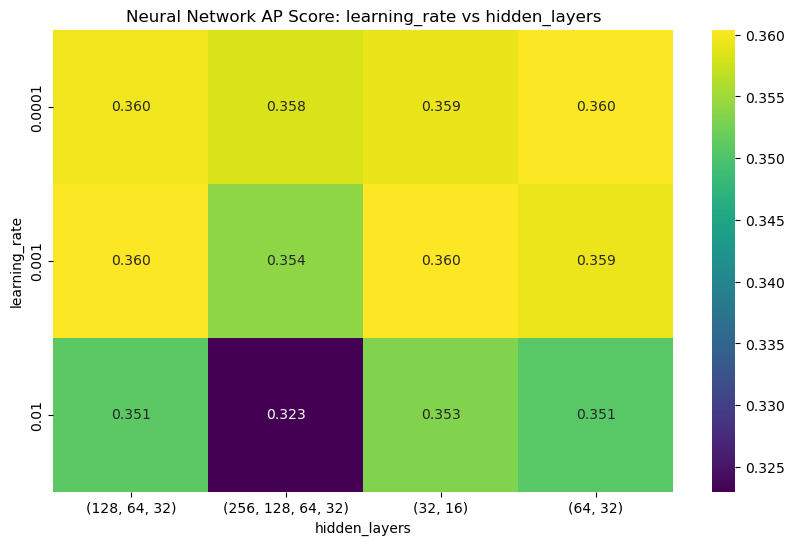

In [ ]:
param_grid = {
    'hidden_layers':  [(64, 32), (32, 16), (128, 64, 32), (256, 128, 64, 32)],
    'learning_rate': [0.01, 0.001, 0.0001],
    'dropout_rate': [0.1, 0.3, 0.5, 0.7],
    'optimizer_name': ['adam', 'adamw'], 
    'loss_name': ['binary_crossentropy']
}

nn_df = run_nn_grid_search(X_resampled_sm, Y_resampled_sm, X_VAL, Y_VAL, X_TEST, Y_TEST, param_grid, model_name="Neural Network")

In [16]:
# Save df 
nn_df.to_csv('nn_grid_search.csv', index=False)

## Evaluation

In [22]:
nn_df.columns

Index(['hidden_layers', 'learning_rate', 'dropout_rate', 'optimizer_name',
       'loss_name', 'Accuracy', 'AUROC', 'AP_Score', 'F1_Macro', 'F1_Binary',
       'Recall', 'Precision'],
      dtype='object')

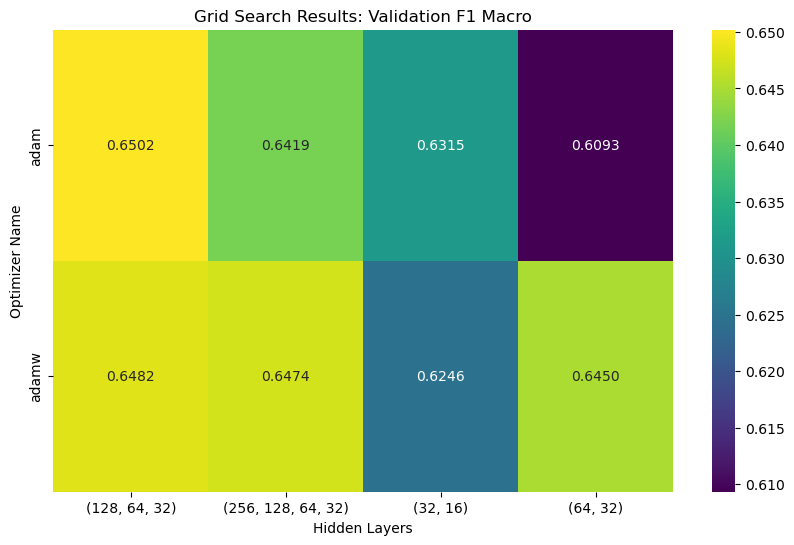


--- TOP 5 MODELS ---
hidden_layers  learning_rate  dropout_rate optimizer_name           loss_name  Accuracy    AUROC  AP_Score  F1_Macro  F1_Binary   Recall  Precision
     (64, 32)           0.01           0.1           adam binary_crossentropy  0.889330 0.750492  0.268216  0.474055   0.006709 0.003373   0.615385
     (64, 32)           0.01           0.1          adamw binary_crossentropy  0.792021 0.763270  0.287460  0.608118   0.339662 0.482715   0.262014
     (64, 32)           0.01           0.3           adam binary_crossentropy  0.889330 0.764811  0.282090  0.478170   0.014969 0.007589   0.545455
     (64, 32)           0.01           0.3          adamw binary_crossentropy  0.883491 0.785663  0.324739  0.591695   0.246526 0.172007   0.434968
     (64, 32)           0.01           0.5           adam binary_crossentropy  0.891152 0.801007  0.348018  0.500601   0.058966 0.030776   0.701923


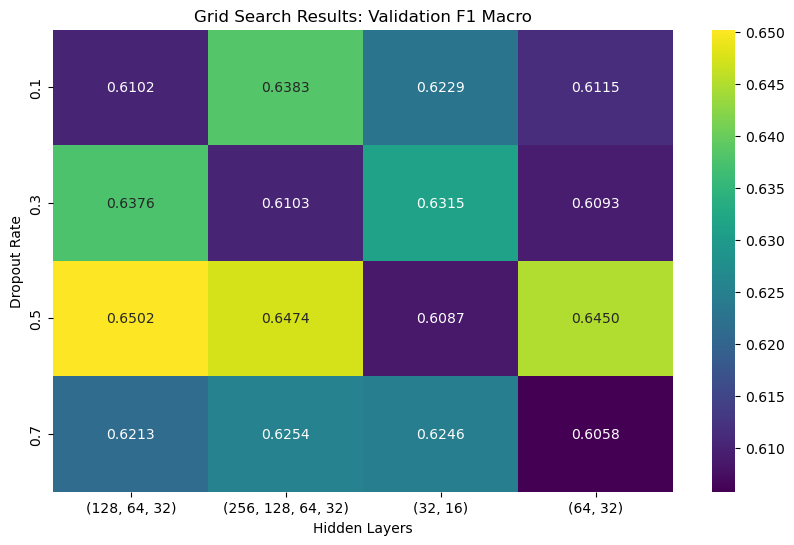


--- TOP 5 MODELS ---
hidden_layers  learning_rate  dropout_rate optimizer_name           loss_name  Accuracy    AUROC  AP_Score  F1_Macro  F1_Binary   Recall  Precision
     (64, 32)           0.01           0.1           adam binary_crossentropy  0.889330 0.750492  0.268216  0.474055   0.006709 0.003373   0.615385
     (64, 32)           0.01           0.1          adamw binary_crossentropy  0.792021 0.763270  0.287460  0.608118   0.339662 0.482715   0.262014
     (64, 32)           0.01           0.3           adam binary_crossentropy  0.889330 0.764811  0.282090  0.478170   0.014969 0.007589   0.545455
     (64, 32)           0.01           0.3          adamw binary_crossentropy  0.883491 0.785663  0.324739  0.591695   0.246526 0.172007   0.434968
     (64, 32)           0.01           0.5           adam binary_crossentropy  0.891152 0.801007  0.348018  0.500601   0.058966 0.030776   0.701923


In [51]:
plot_grid_results(nn_df, index='optimizer_name', columns='hidden_layers', values='F1_Macro')
plot_grid_results(nn_df, index='dropout_rate', columns='hidden_layers', values='F1_Macro')

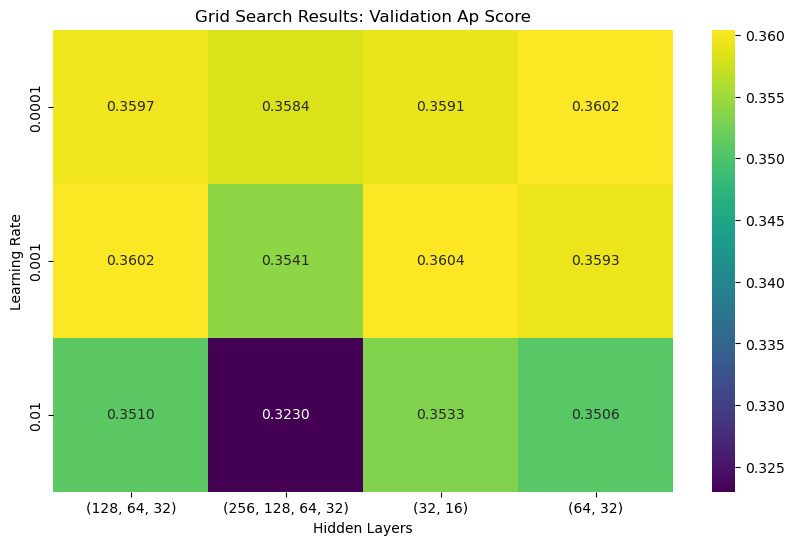


--- TOP 5 MODELS ---
hidden_layers  learning_rate  dropout_rate optimizer_name           loss_name  Accuracy    AUROC  AP_Score  F1_Macro  F1_Binary   Recall  Precision Architecture
     (64, 32)           0.01           0.1           adam binary_crossentropy  0.889330 0.750492  0.268216  0.474055   0.006709 0.003373   0.615385        64-32
     (64, 32)           0.01           0.1          adamw binary_crossentropy  0.792021 0.763270  0.287460  0.608118   0.339662 0.482715   0.262014        64-32
     (64, 32)           0.01           0.3           adam binary_crossentropy  0.889330 0.764811  0.282090  0.478170   0.014969 0.007589   0.545455        64-32
     (64, 32)           0.01           0.3          adamw binary_crossentropy  0.883491 0.785663  0.324739  0.591695   0.246526 0.172007   0.434968        64-32
     (64, 32)           0.01           0.5           adam binary_crossentropy  0.891152 0.801007  0.348018  0.500601   0.058966 0.030776   0.701923        64-32


In [60]:
plot_grid_results(nn_df, index='learning_rate', columns='hidden_layers', values='AP_Score')

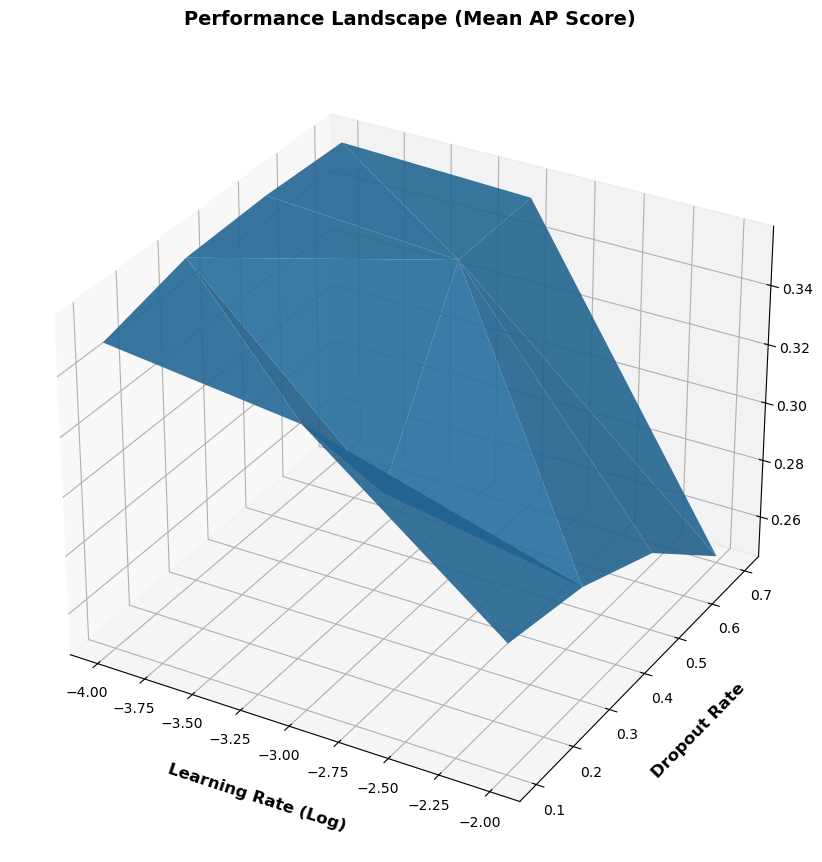

In [59]:
from mpl_toolkits.mplot3d import Axes3D
nn_df = pd.read_csv('nn_grid_search_safe.csv')
nn_df['Architecture'] = nn_df['hidden_layers'].apply(lambda x: x.strip('()').replace(', ', '-'))

surf_data = nn_df.groupby(['learning_rate', 'dropout_rate'])['AP_Score'].mean().reset_index()

# --- Plotting Code ---
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

x = np.log10(surf_data['learning_rate'])
y = surf_data['dropout_rate']
z = surf_data['AP_Score']

# Plot Surface
surf = ax.plot_trisurf(x, y, z, color='#2E86C1', alpha=0.9, shade=True, edgecolor='none')

# Label Styling
ax.set_xlabel('Learning Rate (Log)', labelpad=15, fontsize=12, fontweight='bold')
ax.set_ylabel('Dropout Rate', labelpad=15, fontsize=12, fontweight='bold')
ax.set_zlabel('AP Score', labelpad=15, fontsize=12, fontweight='bold')

ax.set_title('Performance Landscape (Mean AP Score)', fontweight='bold', fontsize=14, pad=20)

# Disable Auto-Rotation for z-label
ax.zaxis.set_rotate_label(False) 
ax.set_zlabel('AP Score', rotation=90)

# Zoom Out
ax.dist = 20

# Adjust Margins
plt.subplots_adjust(left=0.1, right=0.9, bottom=0.1, top=0.9)

plt.savefig('3d_surface_fixed_final.png', dpi=300, bbox_inches='tight', pad_inches=0.5)

/var/folders/dx/vzbc3t9926v711dystt5gjg00000gn/T/ipykernel_44067/3373749061.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_plot = plt.boxplot([nn_df[nn_df['Architecture'] == arch]['AP_Score'] for arch in order],


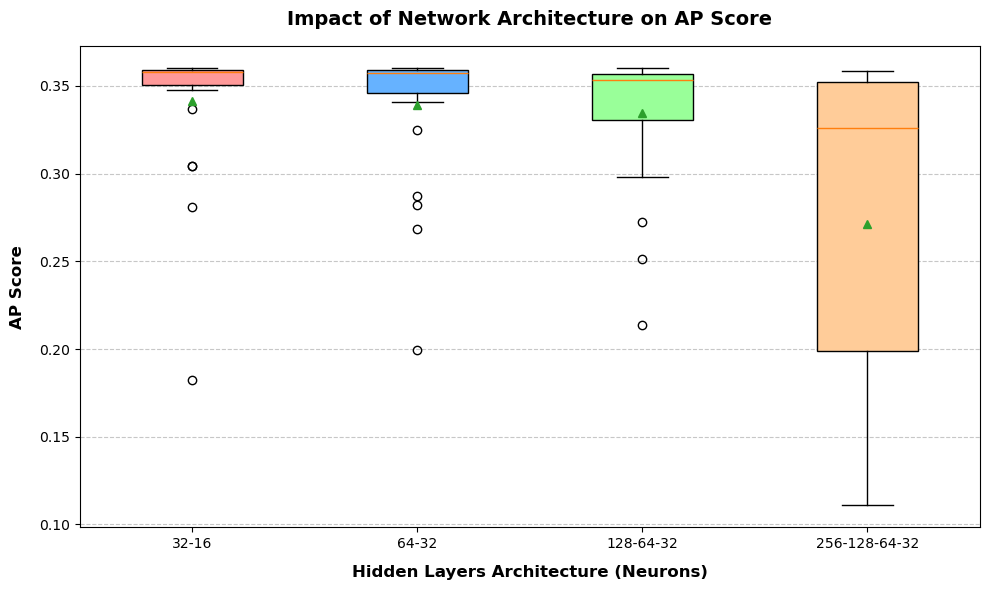

In [62]:
nn_df['Architecture'] = nn_df['hidden_layers'].apply(
    lambda x: x.strip('()').replace('"', '').replace(', ', '-').replace(',', '-')
)

# Determine the order of architectures based on median AP Score for plotting
# This sorts the plot so the "best" performing architecture is on the left or right
order = nn_df.groupby('Architecture')['AP_Score'].median().sort_values(ascending=False).index

# --- Plotting ---
plt.figure(figsize=(10, 6))

# Boxplot
# A boxplot is great here because it shows the spread of results for each architecture
# (due to the varying learning rates, dropouts, etc.)
box_plot = plt.boxplot([nn_df[nn_df['Architecture'] == arch]['AP_Score'] for arch in order],
                       labels=order,
                       patch_artist=True,
                       showmeans=True)

# Customizing colors for a nice look
colors = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99']
for patch, color in zip(box_plot['boxes'], colors):
    patch.set_facecolor(color)

# Styling
plt.title('Impact of Network Architecture on AP Score', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('AP Score', fontsize=12, fontweight='bold', labelpad=10)
plt.xlabel('Hidden Layers Architecture (Neurons)', fontsize=12, fontweight='bold', labelpad=10)
plt.xticks(rotation=0, fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Adjust layout to fit comfortably
plt.tight_layout()

# Save and Show
plt.savefig('layer_size_importance.png', dpi=300)
plt.show()

## Best Models


========== Retraining Best NN (Metric: AP_Score) ==========
Score: 0.3604
Layers: (32, 16) | LR: 0.001 | Dropout: 0.7


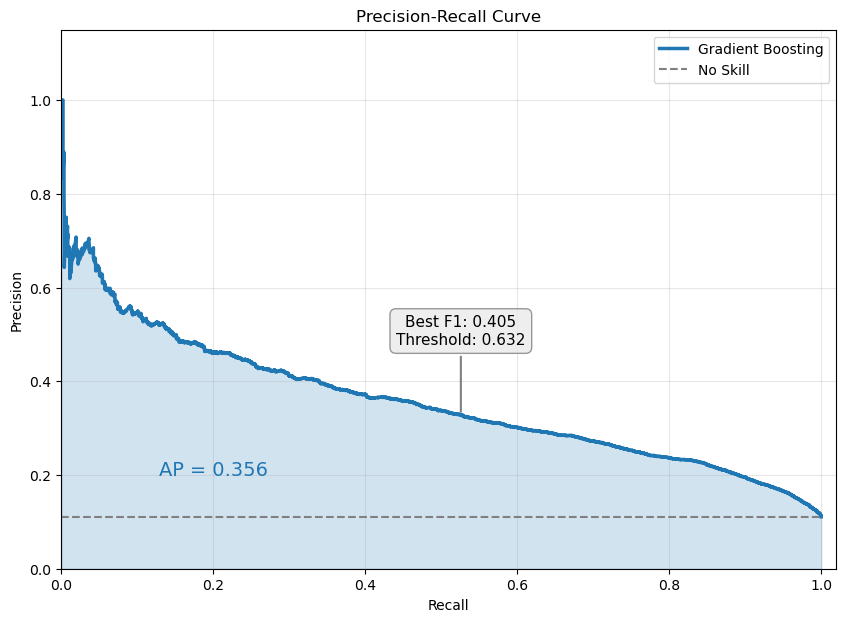

669/669 ━━━━━━━━━━━━━━━━━━━━ 1s 992us/step
Best threshold calculated: 0.6322951912879944


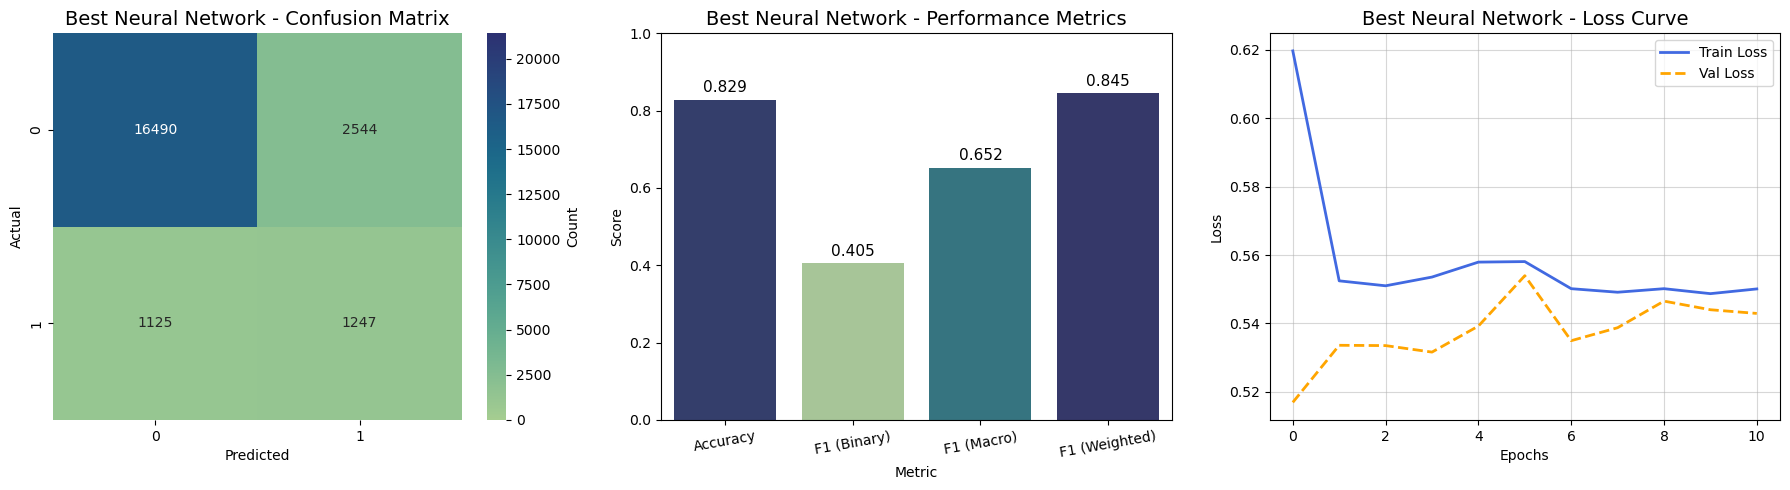

In [ ]:
model_ap = get_best_nn_model(nn_df, 'AP_Score', X_resampled_sm, Y_resampled_sm, X_VAL, Y_VAL, X_TEST, Y_TEST)

## REmove

Processing: StandardScaler...
Training models for ...


Training Models: 100%|██████████| 6/6 [00:31<00:00,  5.31s/it]


Generating model comparison plot...


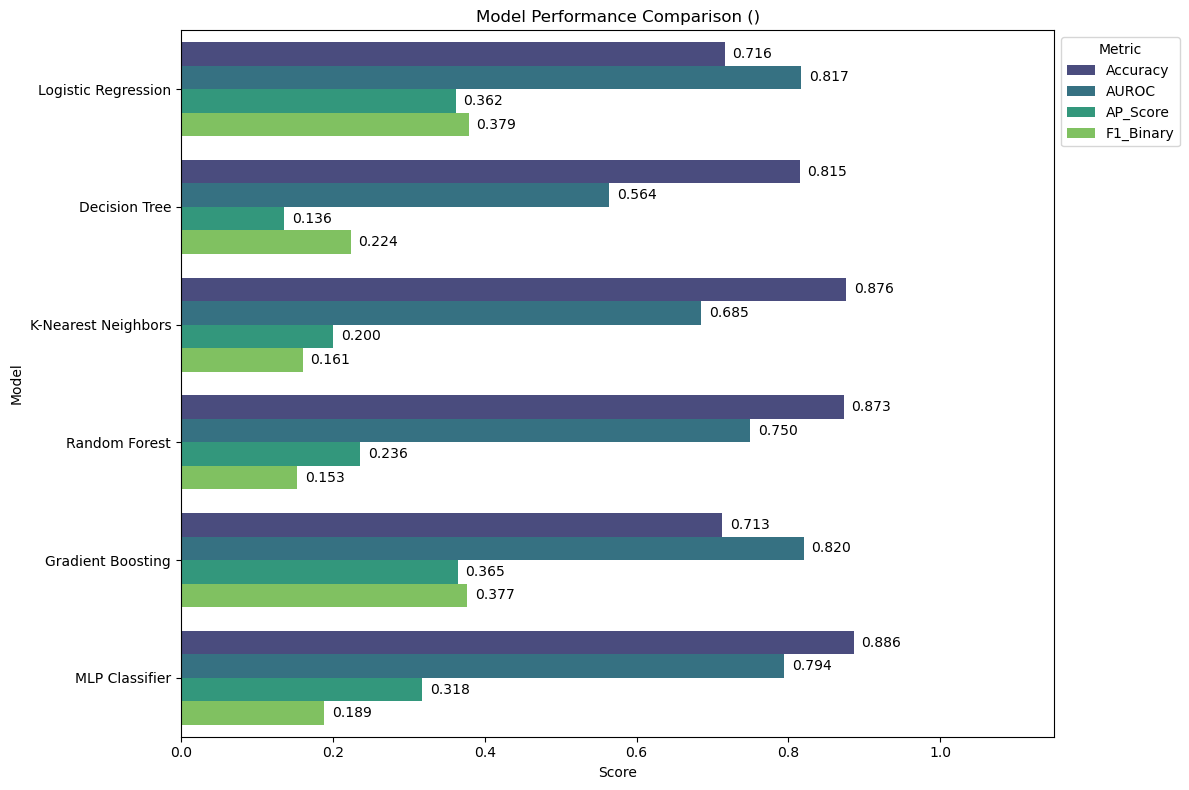

Training models for ...


Training Models: 100%|██████████| 6/6 [01:07<00:00, 11.33s/it]


Generating model comparison plot...


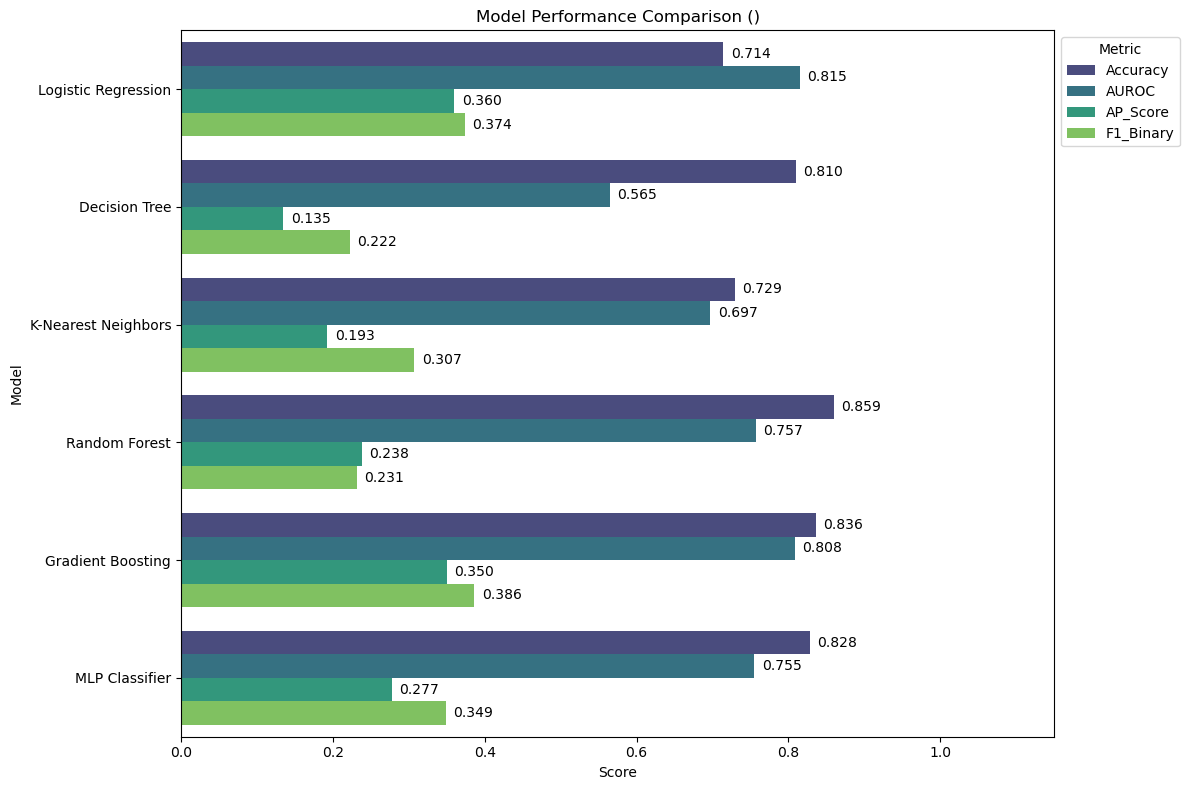

Training models for ...


Training Models: 100%|██████████| 6/6 [00:48<00:00,  8.05s/it]


Generating model comparison plot...


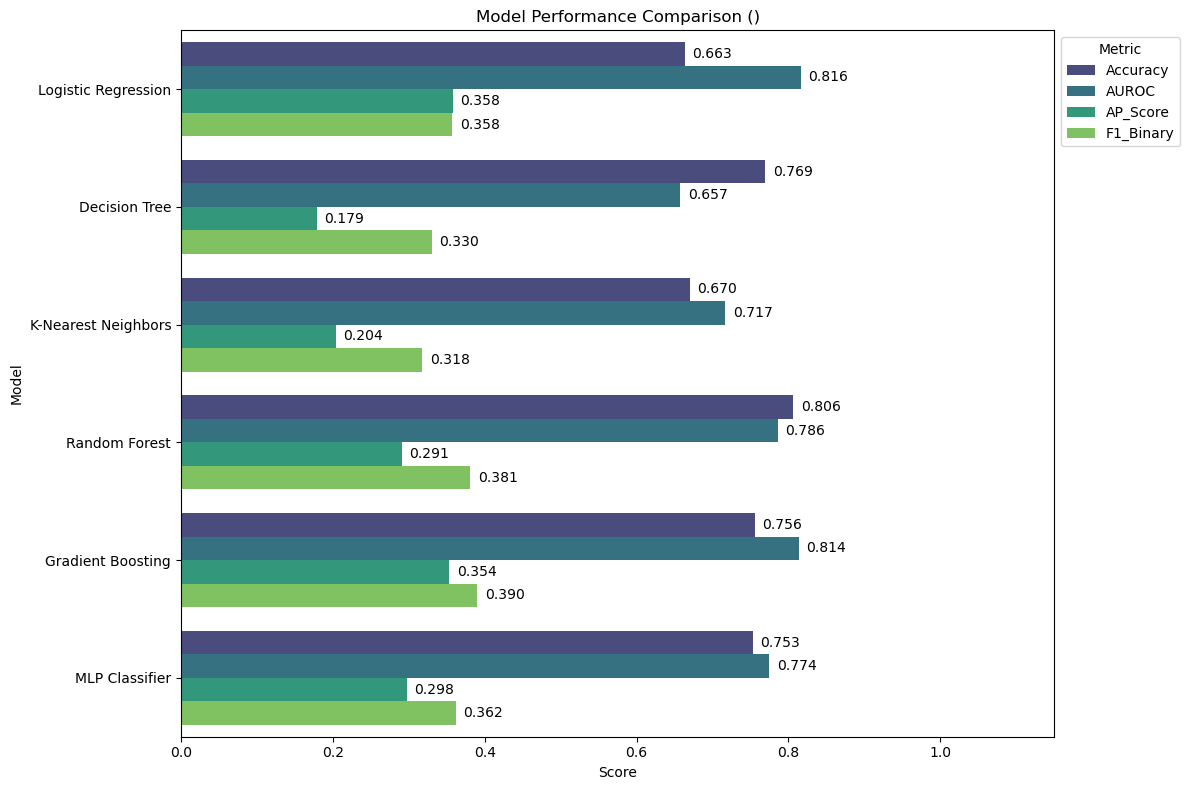

Training models for ...


Training Models: 100%|██████████| 6/6 [01:04<00:00, 10.74s/it]


Generating model comparison plot...


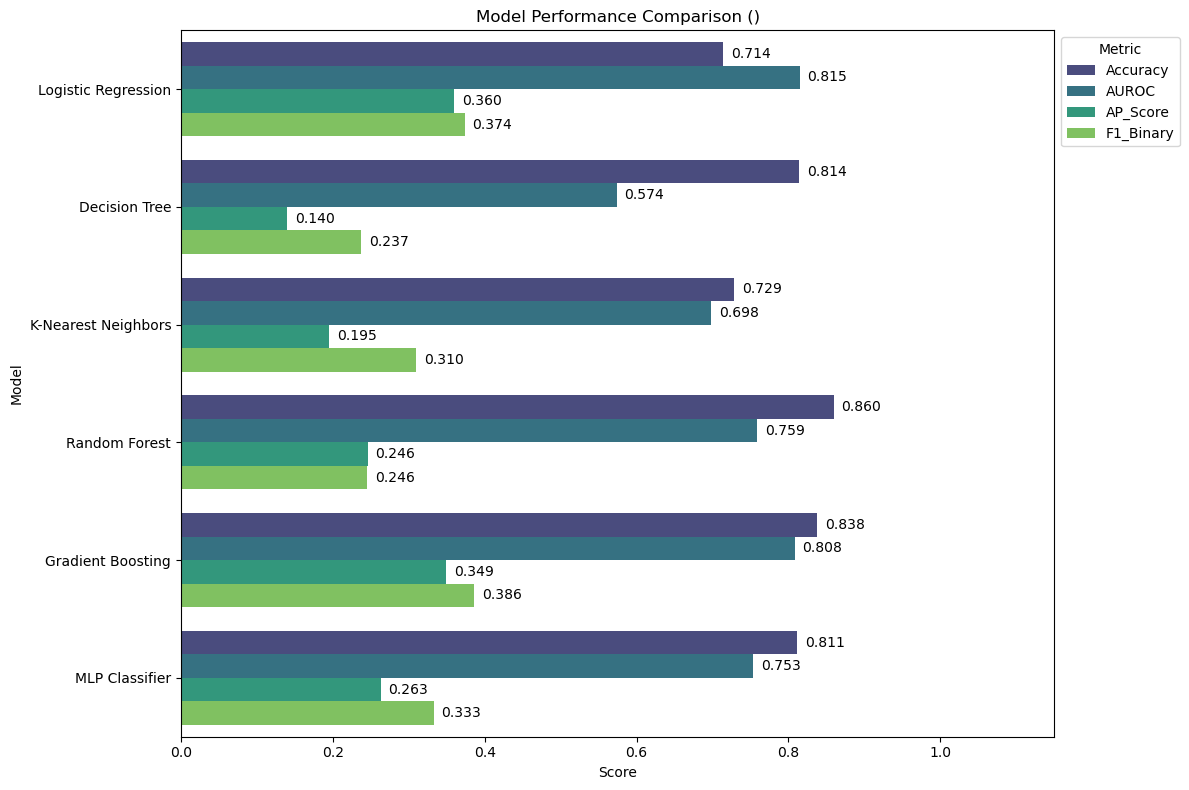

Processing: MinMaxScaler...
Training models for ...


Training Models: 100%|██████████| 6/6 [00:33<00:00,  5.64s/it]


Generating model comparison plot...


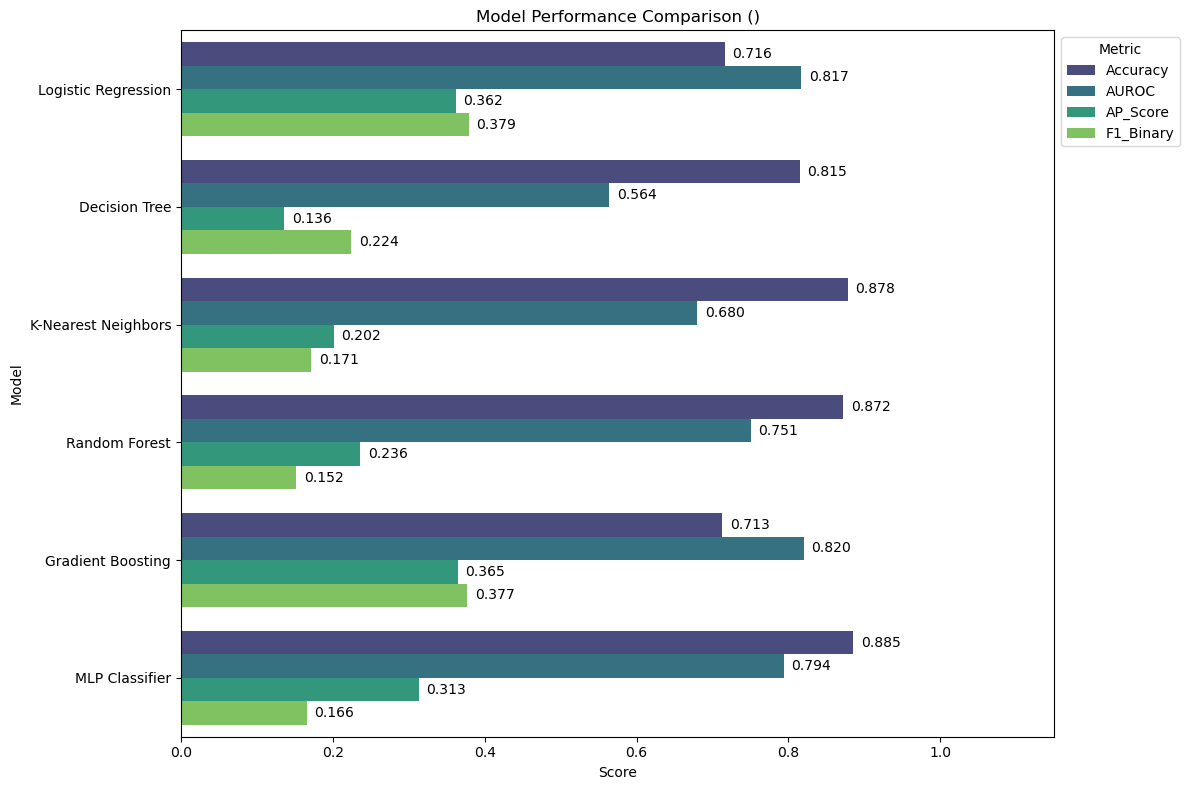

Training models for ...


Training Models: 100%|██████████| 6/6 [00:56<00:00,  9.48s/it]


Generating model comparison plot...


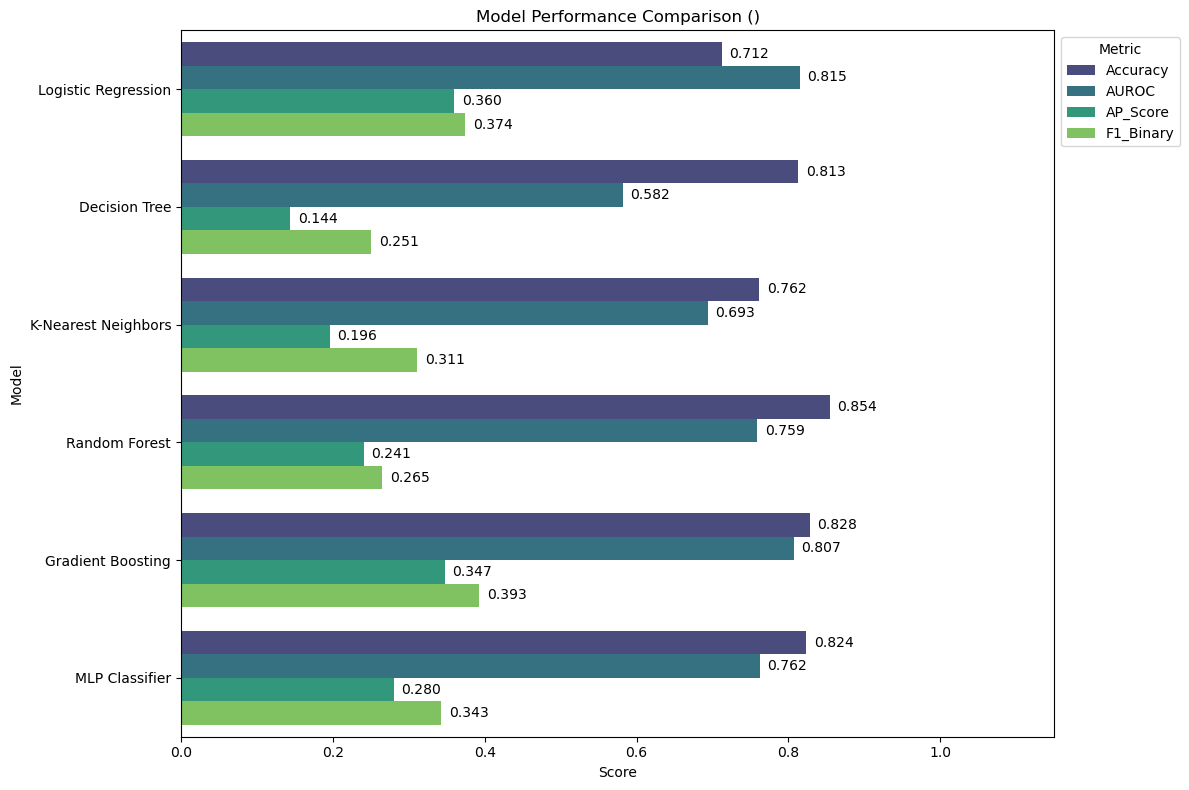

Training models for ...


Training Models: 100%|██████████| 6/6 [01:12<00:00, 12.07s/it]


Generating model comparison plot...


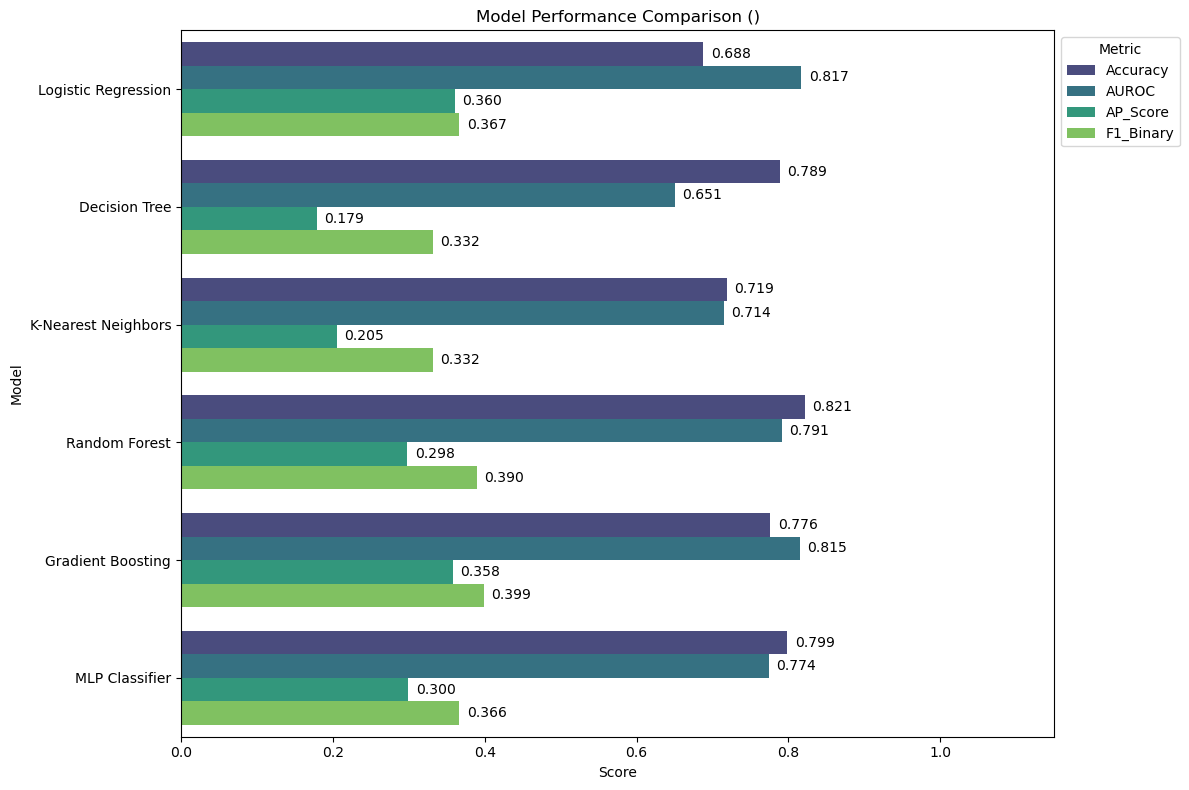

Training models for ...


Training Models: 100%|██████████| 6/6 [00:53<00:00,  8.98s/it]


Generating model comparison plot...


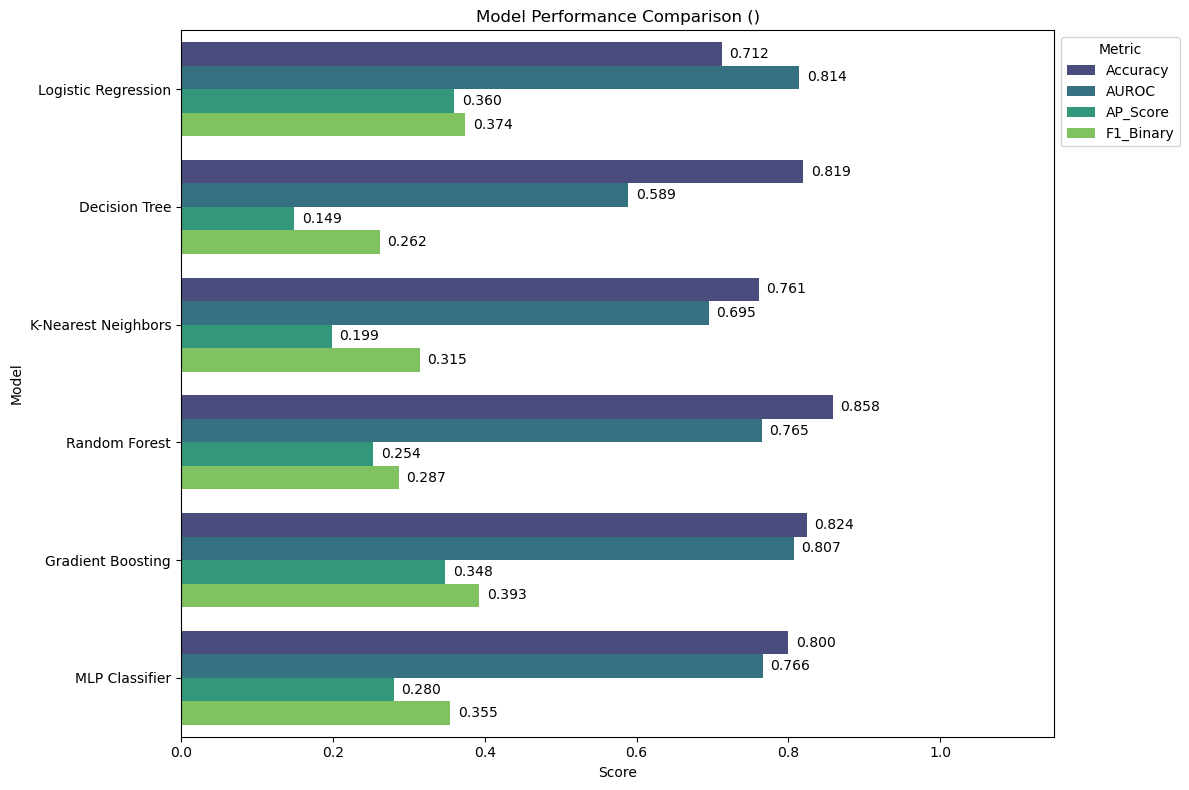

Processing: RobustScaler...
Training models for ...


Training Models: 100%|██████████| 6/6 [00:37<00:00,  6.19s/it]


Generating model comparison plot...


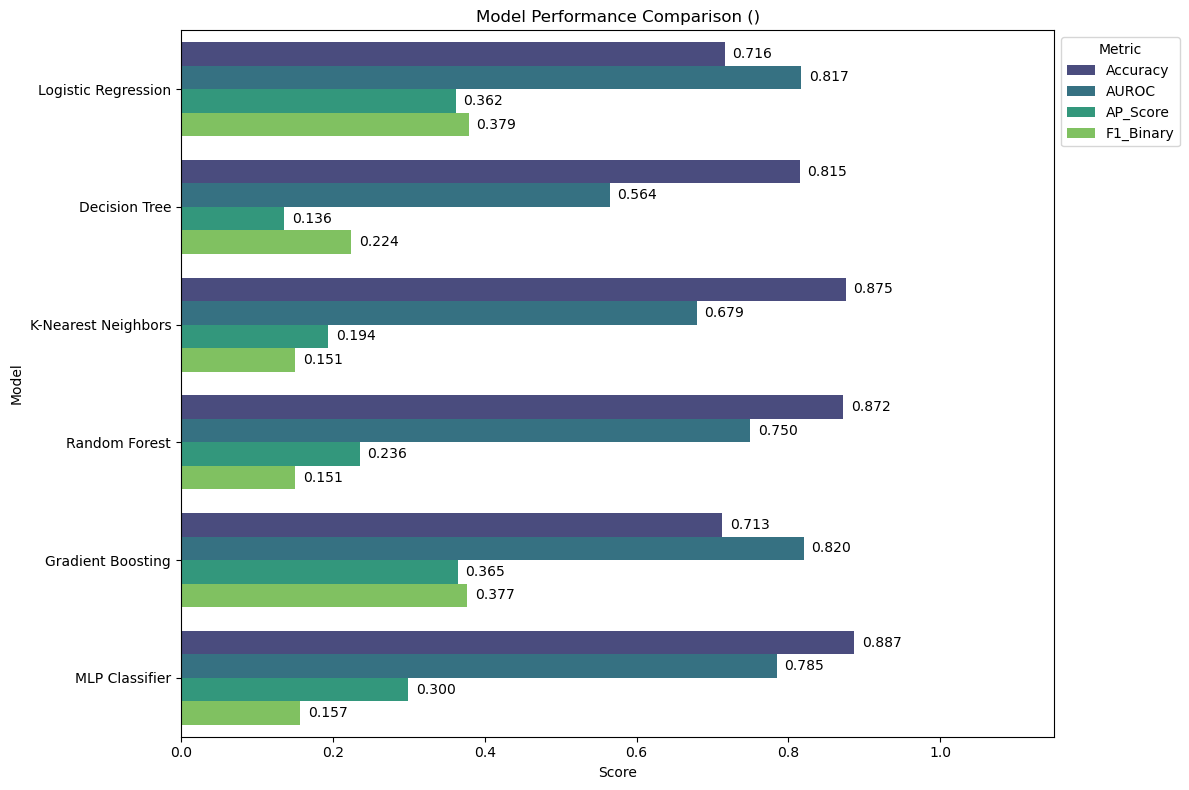

Training models for ...


Training Models: 100%|██████████| 6/6 [01:22<00:00, 13.68s/it]


Generating model comparison plot...


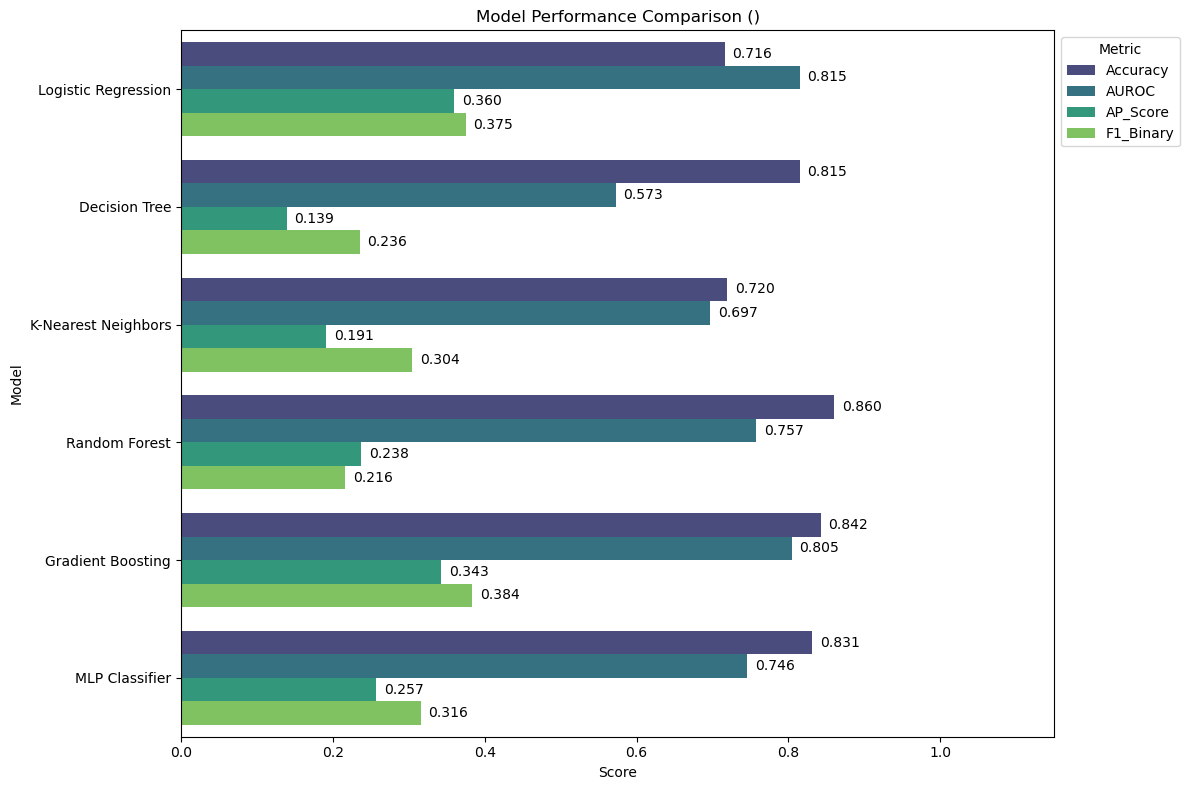

Training models for ...


Training Models: 100%|██████████| 6/6 [00:56<00:00,  9.39s/it]


Generating model comparison plot...


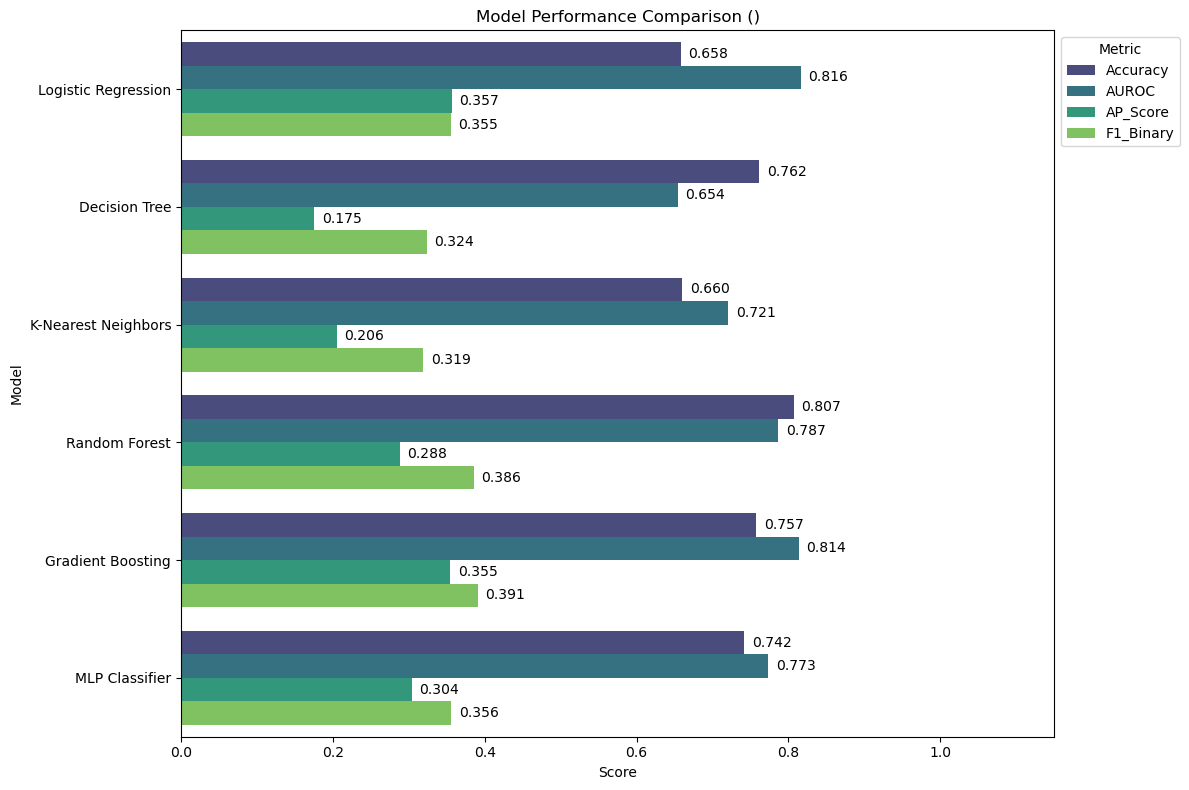

Training models for ...


Training Models: 100%|██████████| 6/6 [01:15<00:00, 12.66s/it]


Generating model comparison plot...


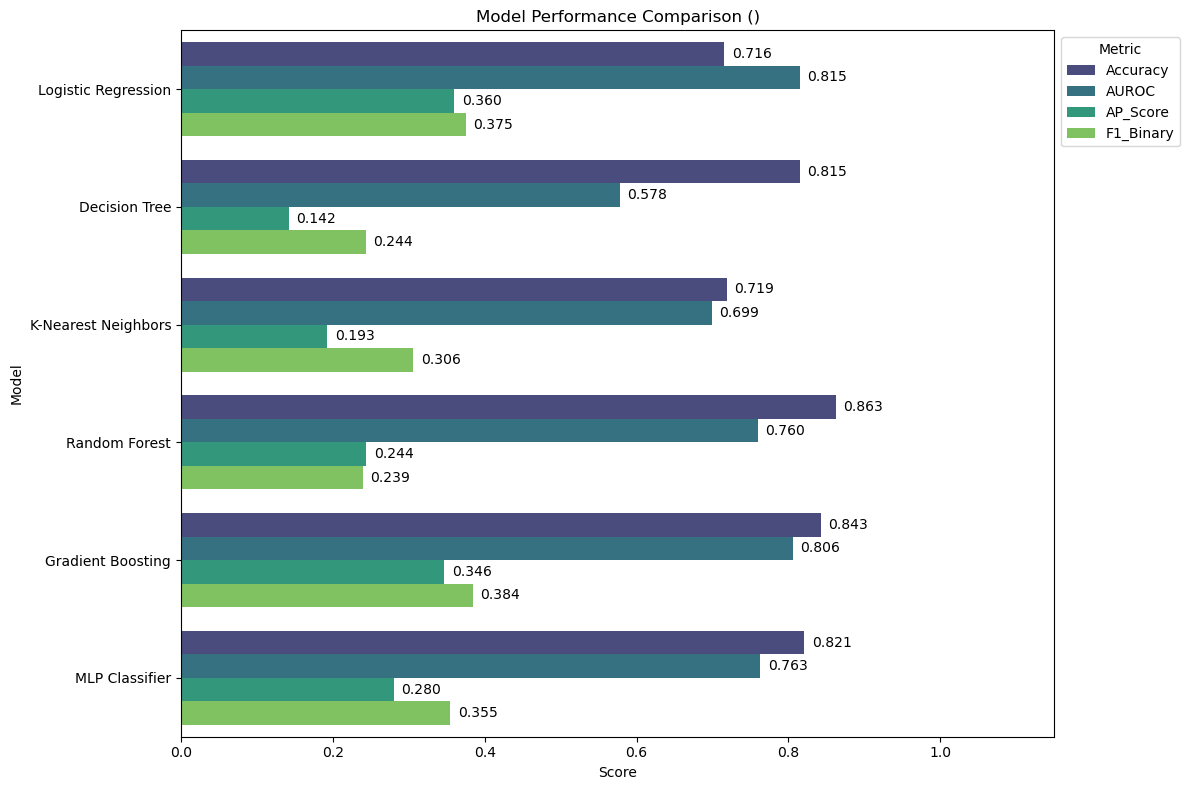

Processing: No Scaling (Trees)...
Training models for ...


Training Models: 100%|██████████| 6/6 [00:30<00:00,  5.16s/it]


Generating model comparison plot...


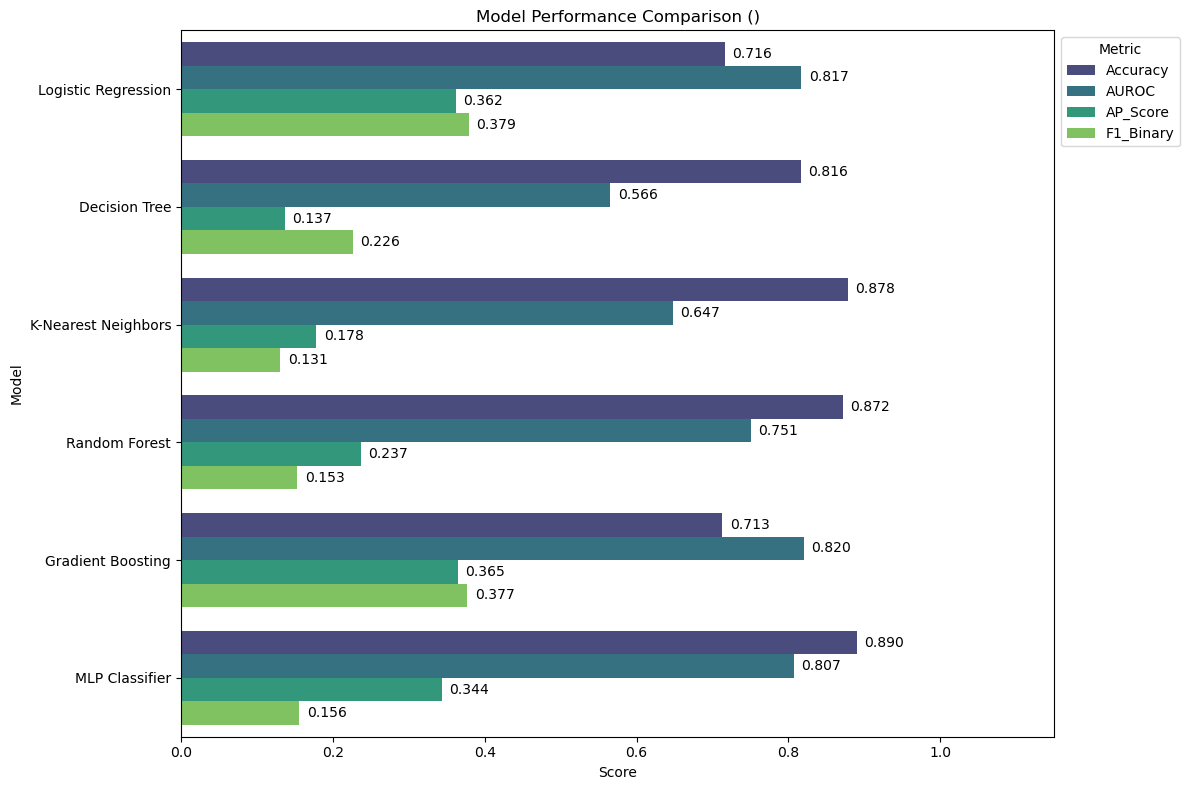

Training models for ...


Training Models: 100%|██████████| 6/6 [01:16<00:00, 12.76s/it]


Generating model comparison plot...


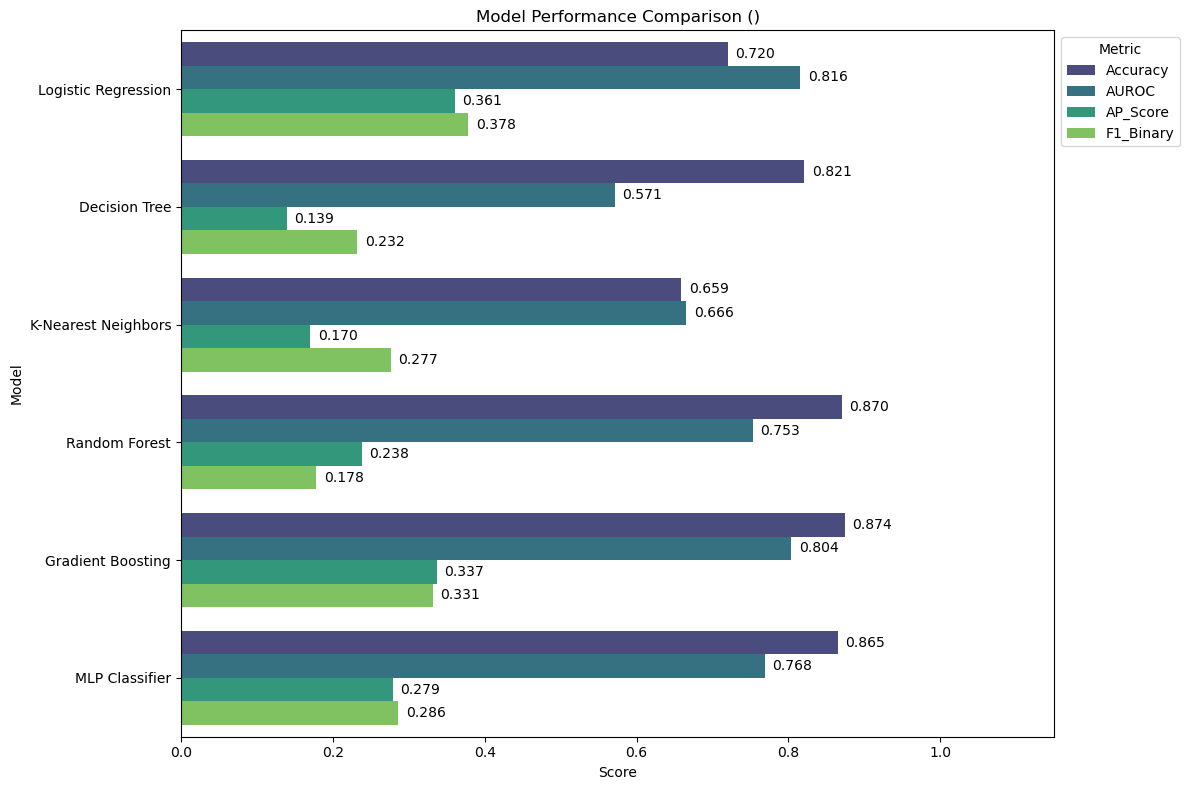

Training models for ...


Training Models: 100%|██████████| 6/6 [00:58<00:00,  9.75s/it]


Generating model comparison plot...


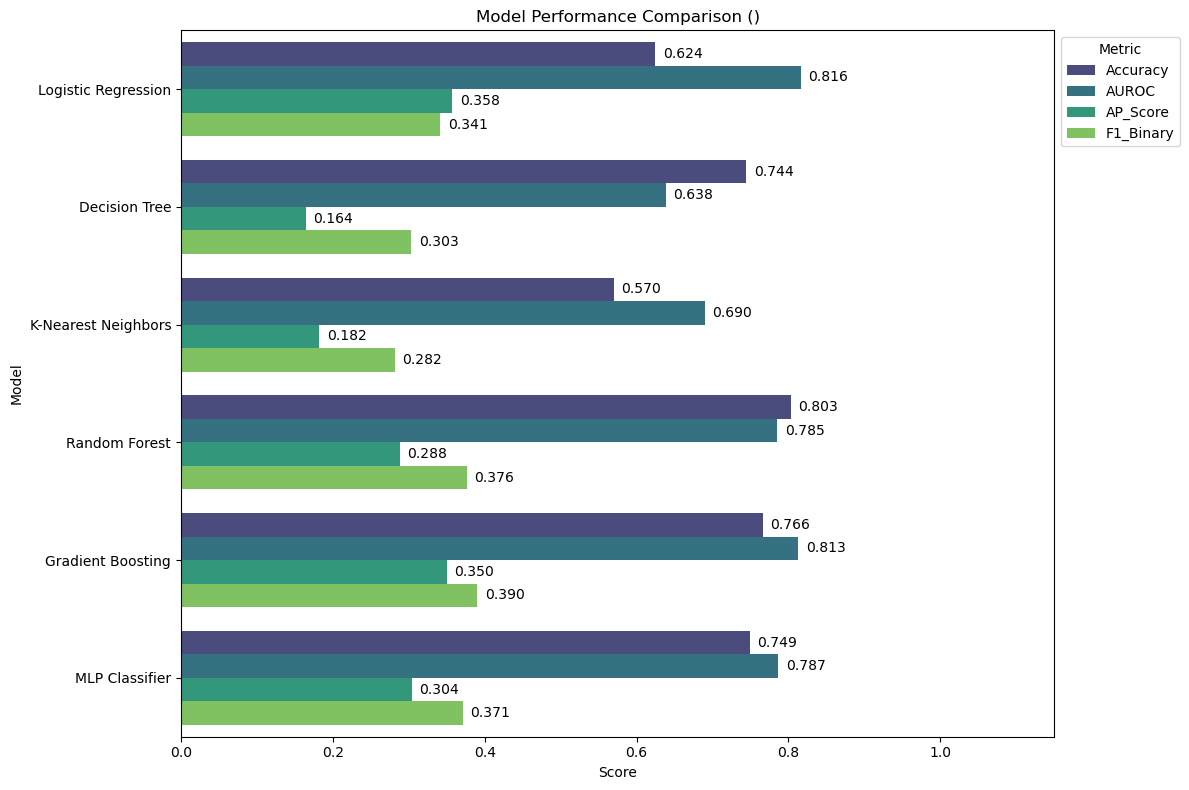

Training models for ...


Training Models: 100%|██████████| 6/6 [01:12<00:00, 12.04s/it]


Generating model comparison plot...


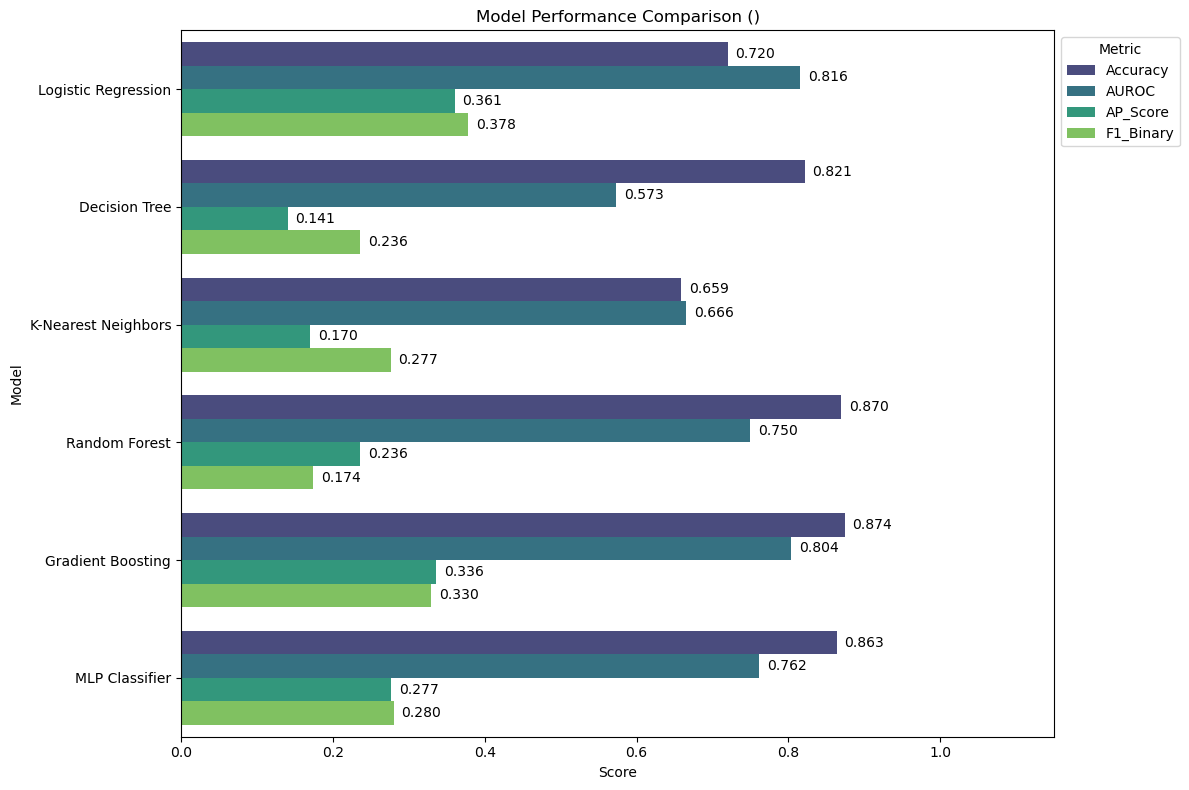

Processing: StandardScaler (All Features)...
Training models for ...


Training Models: 100%|██████████| 6/6 [00:23<00:00,  3.91s/it]


Generating model comparison plot...


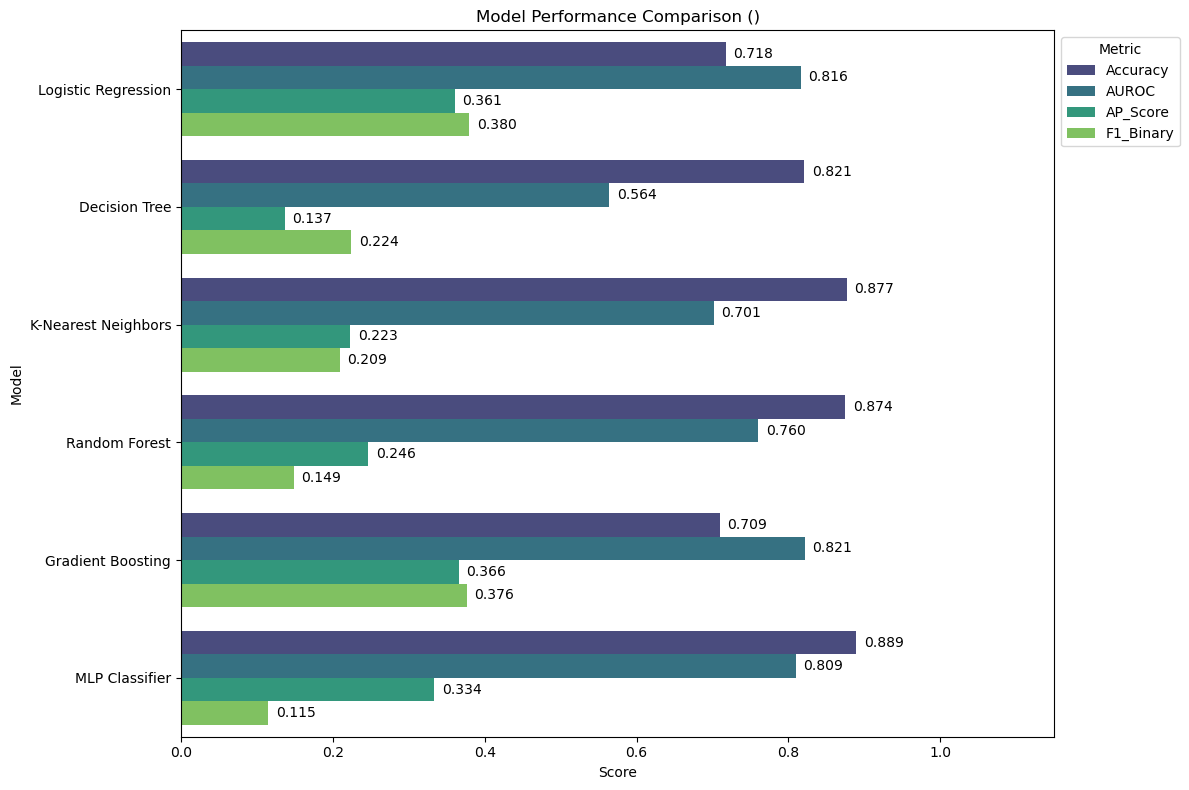

Training models for ...


Training Models: 100%|██████████| 6/6 [01:03<00:00, 10.64s/it]


Generating model comparison plot...


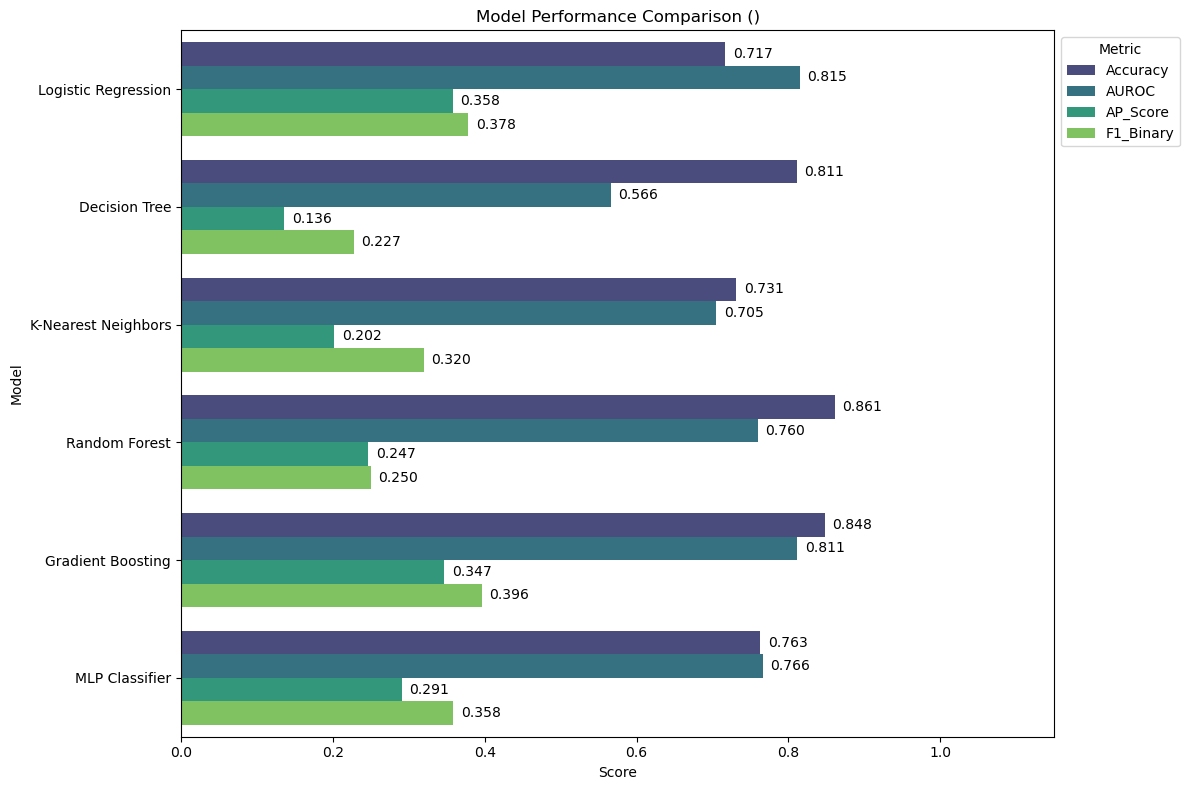

Training models for ...


Training Models: 100%|██████████| 6/6 [00:50<00:00,  8.35s/it]


Generating model comparison plot...


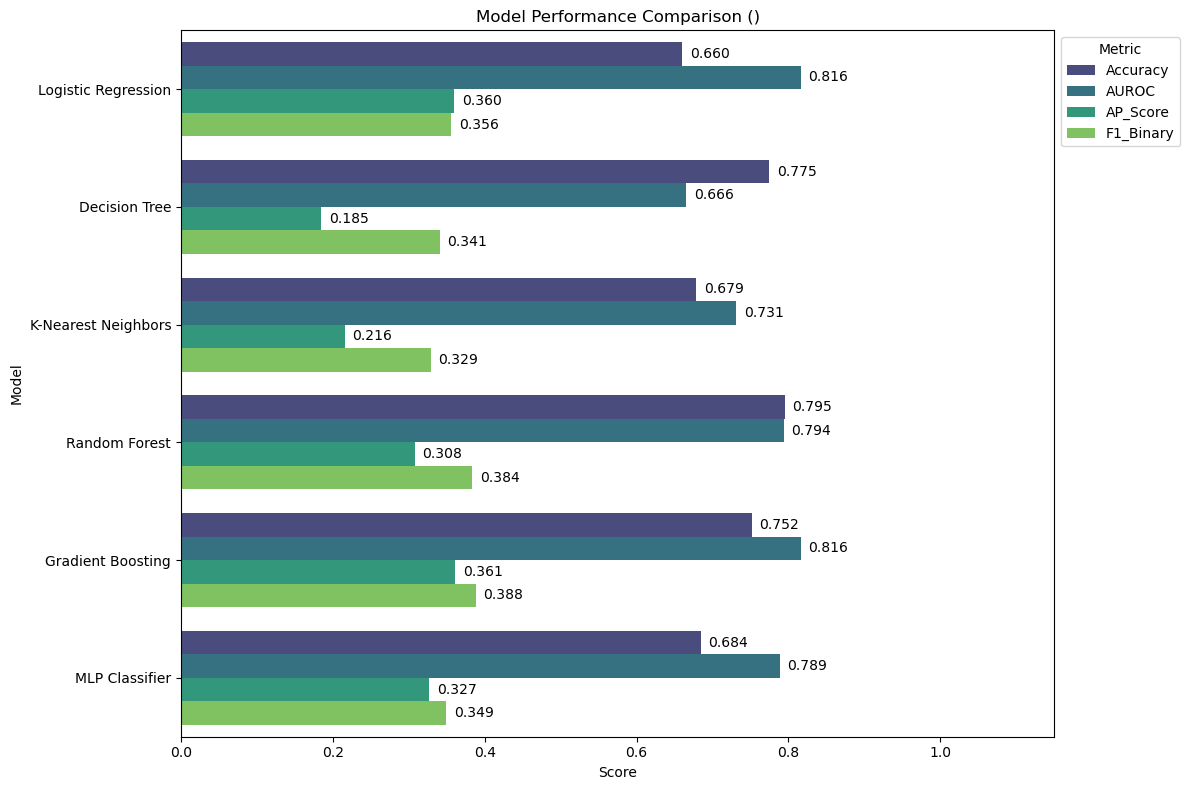

Training models for ...


Training Models: 100%|██████████| 6/6 [00:53<00:00,  8.87s/it]


Generating model comparison plot...


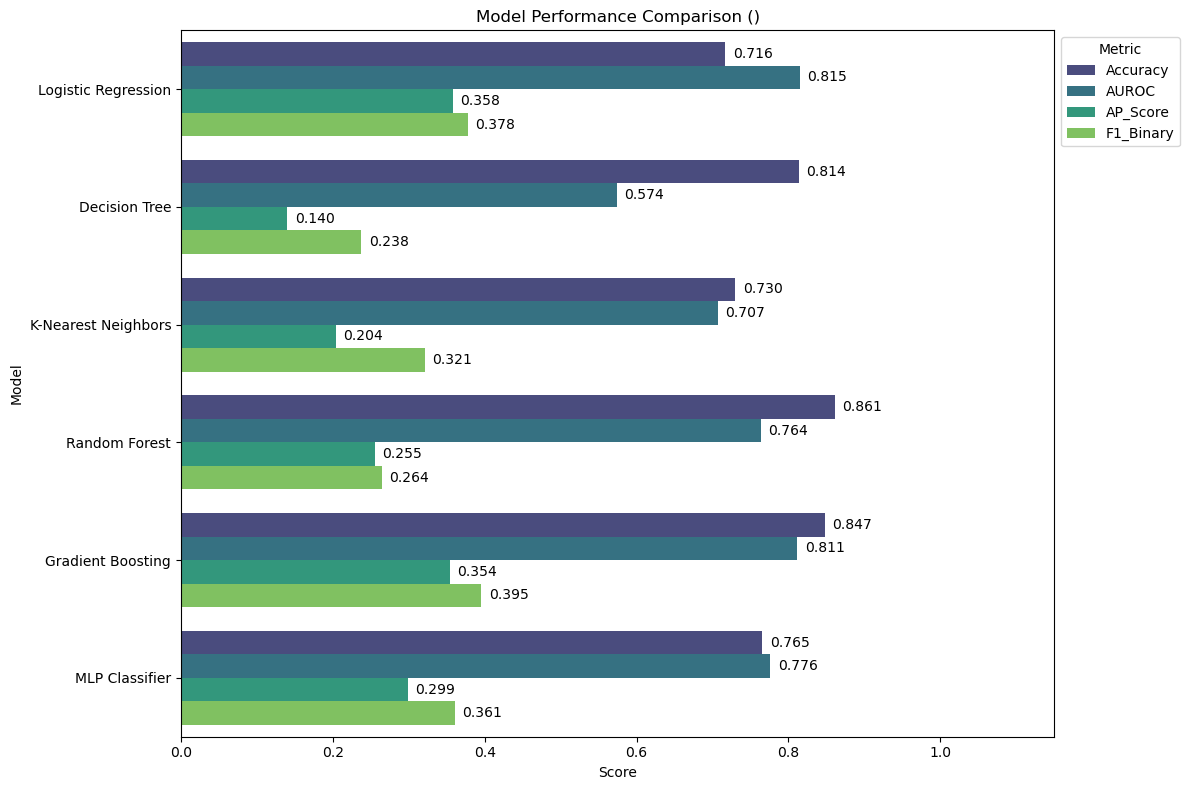

Experiment Complete.


,Model,Accuracy,AUROC,AP_Score,F1_Binary,Preprocessor,Scaling,Resampling
0,Logistic Regression,0.716154,0.816839,0.361785,0.379113,,StandardScaler,Class Weights (Balanced)
1,Decision Tree,0.814772,0.564188,0.135942,0.223919,,StandardScaler,Class Weights (Balanced)
2,K-Nearest Neighbors,0.876016,0.685291,0.200374,0.160658,,StandardScaler,Class Weights (Balanced)
3,Random Forest,0.872793,0.749852,0.236146,0.153033,,StandardScaler,Class Weights (Balanced)
4,Gradient Boosting,0.712931,0.819770,0.364883,0.377217,,StandardScaler,Class Weights (Balanced)
...,...,...,...,...,...,...,...,...
115,Decision Tree,0.813510,0.574096,0.139974,0.237586,,StandardScaler (All Features),SMOTE + Tomek
116,K-Nearest Neighbors,0.730029,0.706663,0.203648,0.321156,,StandardScaler (All Features),SMOTE + Tomek
117,Random Forest,0.861160,0.763609,0.255061,0.264356,,StandardScaler (All Features),SMOTE + Tomek
118,Gradient Boosting,0.847473,0.811444,0.353704,0.395258,,StandardScaler (All Features),SMOTE + Tomek


In [18]:
X_trains = [X_train_standard, X_train_minmax, X_train_robust, X_train_trees, X_train_standard_all]
X_tests = [X_test_standard, X_test_minmax, X_test_robust, X_test_trees, X_test_standard_all]
preprocessor_names = ['StandardScaler', 'MinMaxScaler', 'RobustScaler', 'No Scaling (Trees)', 'StandardScaler (All Features)']

# 1. Storage for all runs
all_results = []

# 2. Helper to process output from run_models
def store_run(df_result, scaler_name, resampling_name):
    """
    Takes the DataFrame from run_models, adds identifying columns, 
    and ensures 'Model' is a column (not index).
    """
    # Make a copy to avoid SettingWithCopy warnings
    temp_df = df_result.copy()
    
    # If Model name is the index, move it to a column
    if temp_df.index.name != 'Model' and 'Model' not in temp_df.columns:
        temp_df = temp_df.reset_index().rename(columns={'index': 'Model'})
        
    # Add the tags for the heatmap dimensions
    temp_df['Scaling'] = scaler_name
    temp_df['Resampling'] = resampling_name
    return temp_df

# 3. Main Loop
for X_tr, X_te, prep_name in zip(X_trains, X_tests, preprocessor_names):
    
    print(f"Processing: {prep_name}...")

    # --- A. Baseline: Class Weights (No Sampling) ---
    # Note: Ensure your run_models passes class_weight='balanced' to the models internally
    df_balanced = run_models(
        X_tr, Y_train, X_te, Y_test, 
        seed=GLOBAL_SEED, 
        n_jobs=N_JOBS, 
        class_weight="balanced"
    )
    all_results.append(store_run(df_balanced, prep_name, "Class Weights (Balanced)"))

    # --- Generate SMOTE Variations for this Scaler ---
    # Assuming get_smotes returns tuple: (X_sm, Y_sm, X_sme, Y_sme, X_smt, Y_smt)
    X_sm, Y_sm, X_sme, Y_sme, X_smt, Y_smt = get_smotes(X_tr, Y_train)

    # --- B. SMOTE ---
    df_sm = run_models(
        X_sm, Y_sm, X_te, Y_test, 
        seed=GLOBAL_SEED, 
        n_jobs=N_JOBS
    )
    all_results.append(store_run(df_sm, prep_name, "SMOTE"))

    # --- C. SMOTE + ENN ---
    df_sme = run_models(
        X_sme, Y_sme, X_te, Y_test, 
        seed=GLOBAL_SEED, 
        n_jobs=N_JOBS
    )
    all_results.append(store_run(df_sme, prep_name, "SMOTE + ENN"))

    # --- D. SMOTE + Tomek ---
    df_smt = run_models(
        X_smt, Y_smt, X_te, Y_test, 
        seed=GLOBAL_SEED, 
        n_jobs=N_JOBS
    )
    all_results.append(store_run(df_smt, prep_name, "SMOTE + Tomek"))

# 4. Combine into one Master DataFrame
final_df = pd.concat(all_results, ignore_index=True)

print("Experiment Complete.")
final_df

In [19]:
# Save to csv
final_df.to_csv('normalisation_comparison_results.csv', index=False)

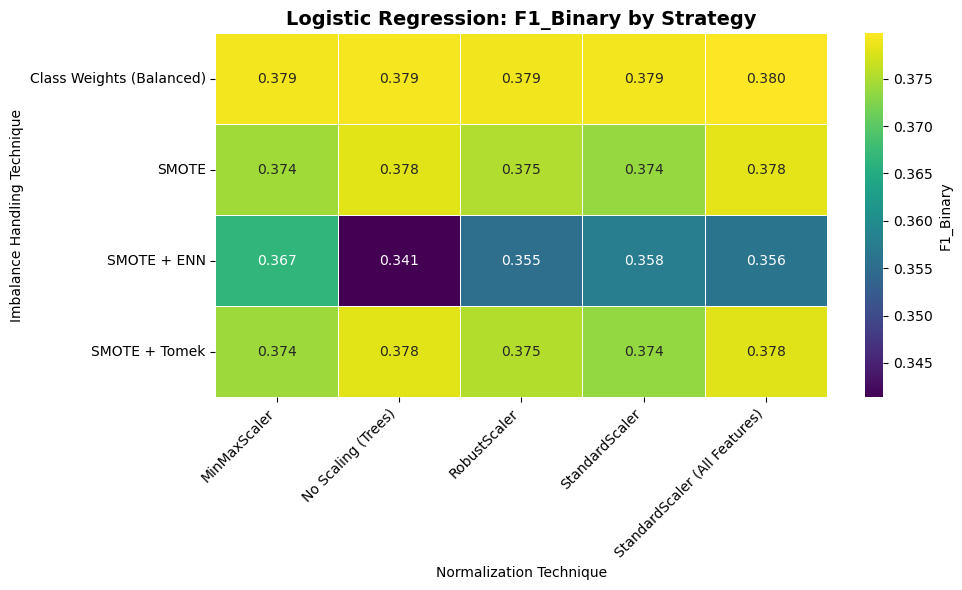

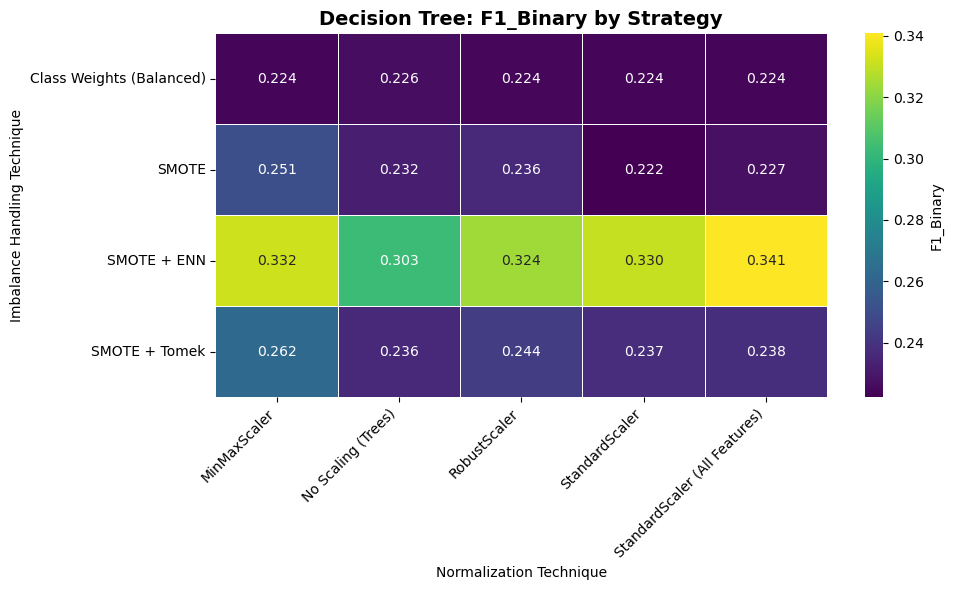

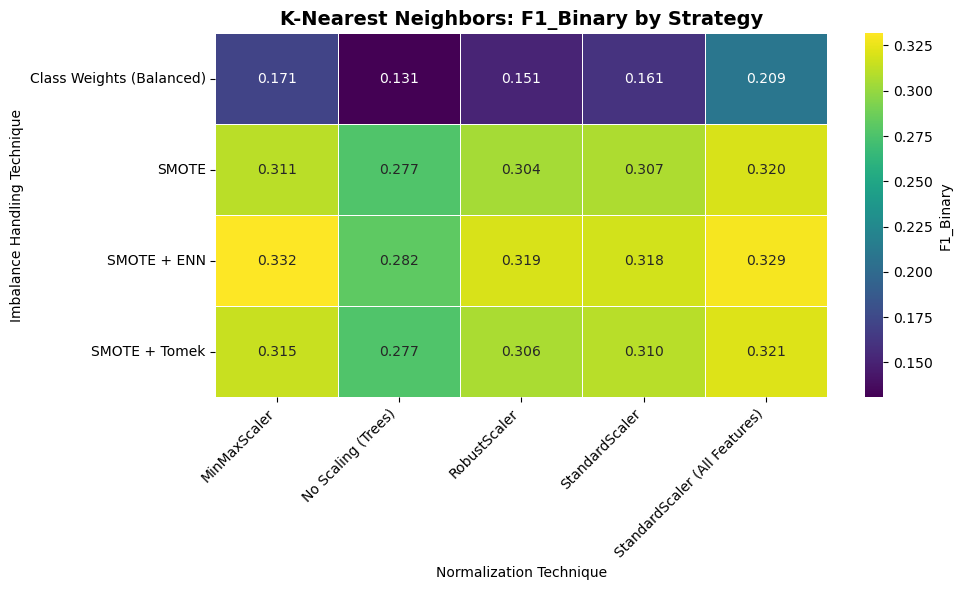

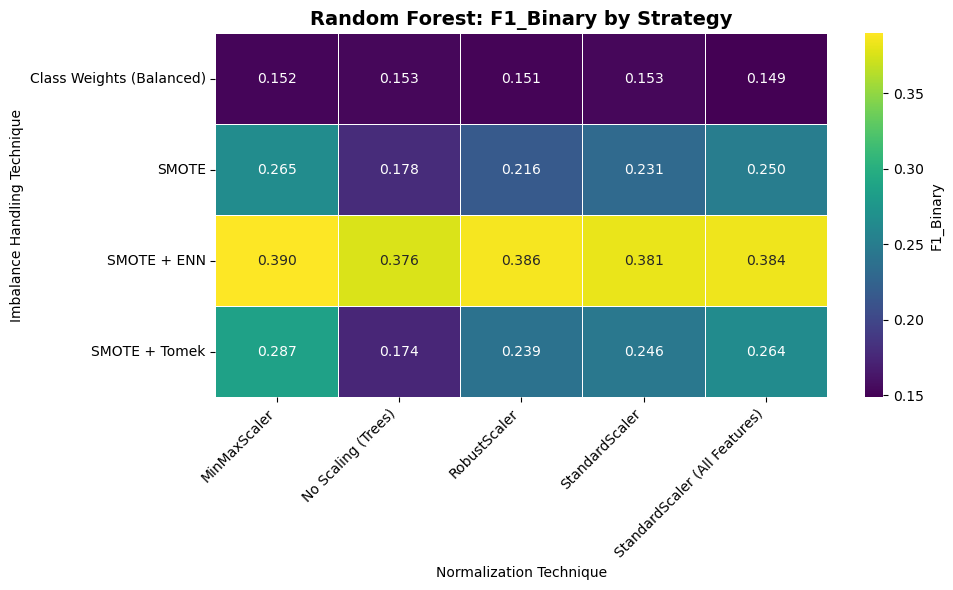

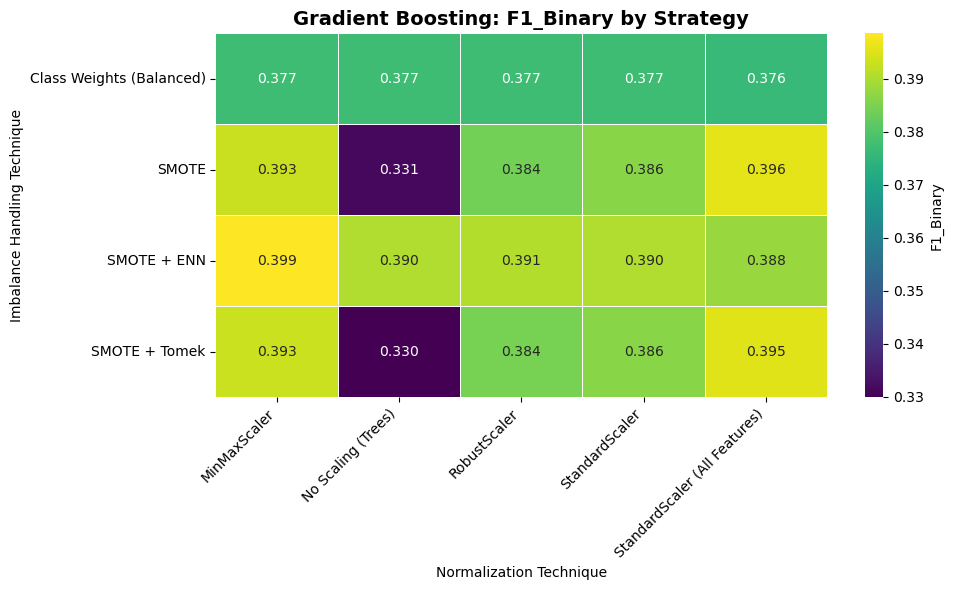

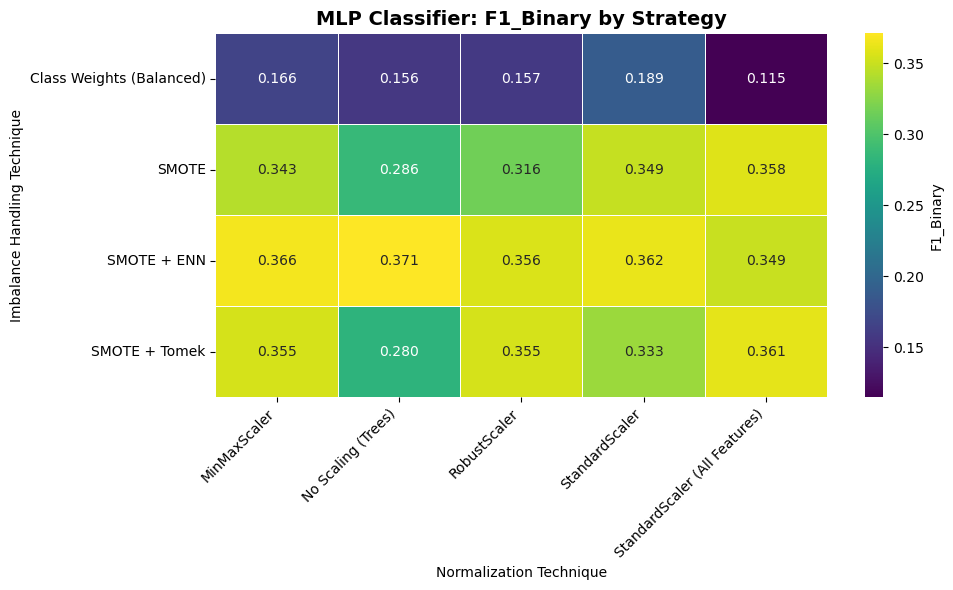

In [20]:
# Get list of unique models
models = final_df['Model'].unique()

# Metric to visualize (e.g., 'AP_Score' is best for imbalance)
metric_to_plot = 'F1_Binary' 

for model in models:
    # 1. Filter data for this specific model
    model_data = final_df[final_df['Model'] == model]
    
    # 2. Pivot: Rows=Resampling, Cols=Scaling, Values=Metric
    heatmap_data = model_data.pivot_table(
        index='Resampling', 
        columns='Scaling', 
        values=metric_to_plot,
        aggfunc='max' # Just in case of duplicates, take max
    )
    
    # 3. Plot
    plt.figure(figsize=(10, 6))
    sns.heatmap(
        heatmap_data, 
        annot=True, 
        fmt=".3f", 
        cmap="viridis", # or "crest"
        linewidths=.5,
        cbar_kws={'label': metric_to_plot}
    )
    
    plt.title(f"{model}: {metric_to_plot} by Strategy", fontsize=14, fontweight='bold')
    plt.xlabel("Normalization Technique")
    plt.ylabel("Imbalance Handling Technique")
    
    # Rotate x labels if they are long
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    
    plt.tight_layout()
    plt.show()

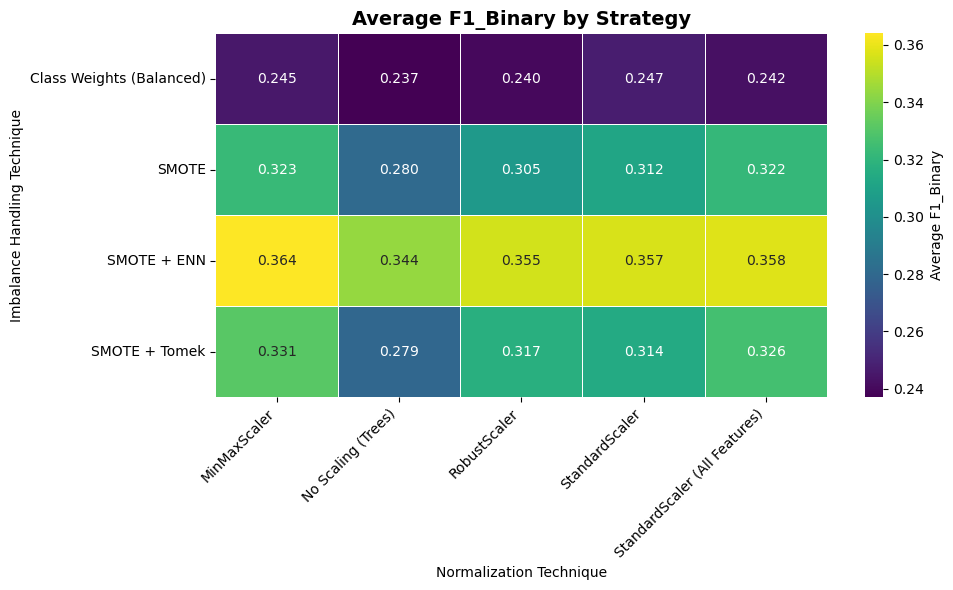

In [21]:
# Plot average over all models
avg_data = final_df.pivot_table(
    index='Resampling', 
    columns='Scaling', 
    values=metric_to_plot,
    aggfunc='mean' # Average over all models
)
plt.figure(figsize=(10, 6))
sns.heatmap(
    avg_data, 
    annot=True, 
    fmt=".3f", 
    cmap="viridis", 
    linewidths=.5,
    cbar_kws={'label': f'Average {metric_to_plot}'}
)
plt.title(f"Average {metric_to_plot} by Strategy", fontsize=14, fontweight='bold')
plt.xlabel("Normalization Technique")
plt.ylabel("Imbalance Handling Technique")

# Rotate x labels if they are long
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## TabNET

In [22]:
from pytorch_tabnet.tab_model import TabNetClassifier
import torch

weights = torch.tensor([1.0, 4.0], dtype=torch.float32)

clf = TabNetClassifier(
    optimizer_params=dict(lr=2e-2),
    scheduler_params={"step_size":10, "gamma":0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    verbose=1
)

# 3. Train (Using the NumPy arrays we created in Part 1)
clf.fit(
    X_TRAIN, Y_TRAIN,
    loss_fn=torch.nn.CrossEntropyLoss(weight=weights), 
    eval_set=[(X_VAL, Y_VAL)],
    eval_name=['valid'],
    eval_metric=['auc', 'accuracy'],
    max_epochs=50, 
    patience=10,
    batch_size=1024, 
    virtual_batch_size=128,
    num_workers=0,
    drop_last=False
)

/Users/mats/miniconda3/envs/ML/lib/python3.11/site-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.59004 | valid_auc: 0.75505 | valid_accuracy: 0.86161 |  0:00:10s
epoch 1  | loss: 0.53758 | valid_auc: 0.77233 | valid_accuracy: 0.81023 |  0:00:20s
epoch 2  | loss: 0.51667 | valid_auc: 0.79161 | valid_accuracy: 0.81513 |  0:00:30s
epoch 3  | loss: 0.50503 | valid_auc: 0.80047 | valid_accuracy: 0.81035 |  0:00:40s
epoch 4  | loss: 0.49868 | valid_auc: 0.79923 | valid_accuracy: 0.81268 |  0:00:51s
epoch 5  | loss: 0.50042 | valid_auc: 0.80115 | valid_accuracy: 0.8128  |  0:01:01s
epoch 6  | loss: 0.4973  | valid_auc: 0.80403 | valid_accuracy: 0.81852 |  0:01:11s
epoch 7  | loss: 0.49375 | valid_auc: 0.80321 | valid_accuracy: 0.81852 |  0:01:22s
epoch 8  | loss: 0.49275 | valid_auc: 0.80493 | valid_accuracy: 0.80042 |  0:01:32s
epoch 9  | loss: 0.49077 | valid_auc: 0.80692 | valid_accuracy: 0.80953 |  0:01:42s
epoch 10 | loss: 0.48825 | valid_auc: 0.80691 | valid_accuracy: 0.80089 |  0:01:53s

Early stopping occurred at epoch 10 with best_epoch = 0 and best_valid_accu

/Users/mats/miniconda3/envs/ML/lib/python3.11/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Best threshold calculated: 1


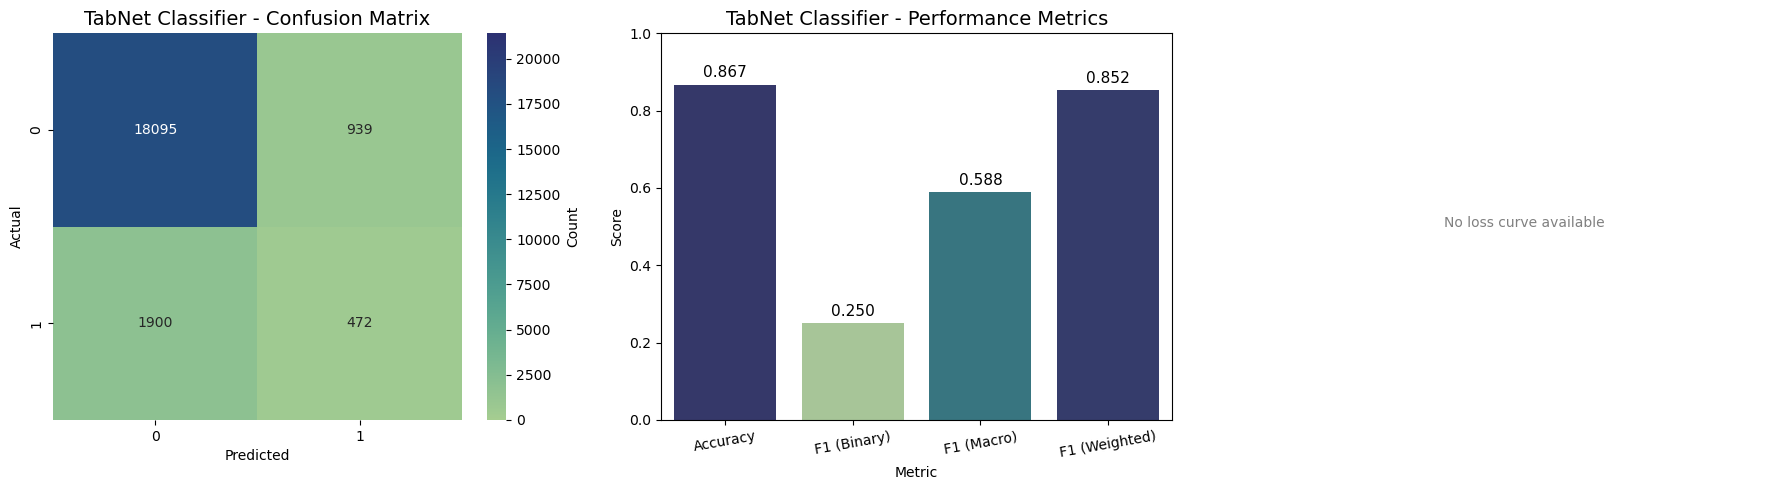

(0.8673736335606839,
 0.24953740417657944,
 0.5883983108407558,
 0.8521608272771992)

In [31]:
# Evaluate
preds = clf.predict_proba(X_TEST)[:, 1]
evaluate_model(X_TEST, Y_TEST, clf, model_name="TabNet Classifier", threshold=True)